In [109]:
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

Brown (2019): https://github.com/IrinaStatsLab/Awesome-CGM/wiki/Brown-(2019)

Quick statistics:

* 168 patients
* no. of recorded events by patient vary from 36,220 to 57,756
* the date range across all patients is from 4.08.2016 to 25.03.2019
* continuous recorded periods for each patient vary from 183 to 204 days with one exeption where one patient had 846 days worth of recorded events

In [110]:
dclp3 = pd.read_csv("C:/Users/meril/Desktop/Projekt_ML/DCLP3/Data Files/cgm.txt", sep="|")

In [158]:
dclp3

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min,time_period,CGM_mmol,in_range,CGM_mmol_diff,rolling_mean_mmol,rolling_std_mmol,delta_from_mean,CGM_category,weekday_name
0,1,1. Baseline,2017-12-11 23:59:25,172,2017-12-11,23:59:25,23,59,1439,NaN,21:00–00:00,9.555556,True,NaN,9.555556,NaN,0.000000,in_range,Monday
1,1,1. Baseline,2017-12-12 00:04:24,170,2017-12-12,00:04:24,0,4,4,4.983333,00:00–03:00,9.444444,True,-0.111111,9.500000,0.078567,-0.055556,in_range,Tuesday
2,1,1. Baseline,2017-12-12 00:09:24,167,2017-12-12,00:09:24,0,9,9,5.000000,00:00–03:00,9.277778,True,-0.166667,9.425926,0.139812,-0.148148,in_range,Tuesday
3,1,1. Baseline,2017-12-12 00:14:25,163,2017-12-12,00:14:25,0,14,14,5.016667,00:00–03:00,9.055556,True,-0.222222,9.333333,0.217543,-0.277778,in_range,Tuesday
4,1,1. Baseline,2017-12-12 00:19:25,160,2017-12-12,00:19:25,0,19,19,5.000000,00:00–03:00,8.888889,True,-0.166667,9.166667,0.244276,-0.277778,in_range,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4292120,171,2. Post Randomization,2018-10-24 08:50:04,174,2018-10-24,08:50:04,8,50,530,5.000000,03:00–09:00,9.666667,True,0.333333,9.347222,0.232958,0.319444,in_range,Wednesday
4292121,171,2. Post Randomization,2018-10-24 08:55:04,192,2018-10-24,08:55:04,8,55,535,5.000000,03:00–09:00,10.666667,False,1.000000,9.736111,0.643702,0.930556,hyperglycemia,Wednesday
4292122,171,2. Post Randomization,2018-10-24 09:00:04,189,2018-10-24,09:00:04,9,0,540,5.000000,09:00–12:00,10.500000,False,-0.166667,10.041667,0.643702,0.458333,hyperglycemia,Wednesday
4292123,171,2. Post Randomization,2018-10-24 09:05:04,183,2018-10-24,09:05:04,9,5,545,5.000000,09:00–12:00,10.166667,False,-0.333333,10.250000,0.440959,-0.083333,hyperglycemia,Wednesday


# Time-series models :)

**Statsmodels**
*   Augmented Dickey-Fuller (ADF) test adfuller, 
*   Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test,
* autocorrelation function (ACF) plot_acf
* partial autocorrelation function (PACF) plot_pacf,
* autoregressive integrated moving average (ARIMA) model
* Seasonal ARIMA -- SARIMAX

In [210]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
register_matplotlib_converters()
from time import time

from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

In [211]:
print("Hourly summary (% of each zone):")
print(hourly_summary)

Hourly summary (% of each zone):
zone  TAR (>10)   TBR (<4)  TIR (4–10)
hour                                  
0     34.693878   4.081633   61.224490
1     37.037037   5.925926   57.037037
2     41.610738   3.355705   55.033557
3     29.850746   0.746269   69.402985
4     25.165563   0.662252   74.172185
5     10.769231   0.000000   89.230769
6      9.022556   0.751880   90.225564
7     11.267606   6.338028   82.394366
8     12.765957   7.092199   80.141844
9     28.965517   6.206897   64.827586
10    52.027027   0.000000   47.972973
11    48.920863   0.000000   51.079137
12    23.529412   6.617647   69.852941
13    33.103448   5.517241   61.379310
14    57.823129   9.523810   32.653061
15    46.575342   2.739726   50.684932
16    32.121212   0.000000   67.878788
17    27.586207   4.022989   68.390805
18    16.000000  12.571429   71.428571
19    29.824561   0.584795   69.590643
20    43.258427   3.932584   52.808989
21    35.119048   0.000000   64.880952
22    33.136095   1.775148   65

### Trying to make data stationary

In [212]:
patient_id = 1
subset = dclp3[dclp3['PtID'] == patient_id].sort_values('DataDtTm').copy()
subset = subset.set_index('DataDtTm')['CGM_mmol']
subset

DataDtTm
2017-12-11 23:59:25     9.555556
2017-12-12 00:04:24     9.444444
2017-12-12 00:09:24     9.277778
2017-12-12 00:14:25     9.055556
2017-12-12 00:19:25     8.888889
                         ...    
2018-07-02 23:37:32    12.611111
2018-07-02 23:42:33    12.888889
2018-07-02 23:47:33    13.444444
2018-07-02 23:52:32    14.111111
2018-07-02 23:57:33    14.611111
Name: CGM_mmol, Length: 57016, dtype: float64

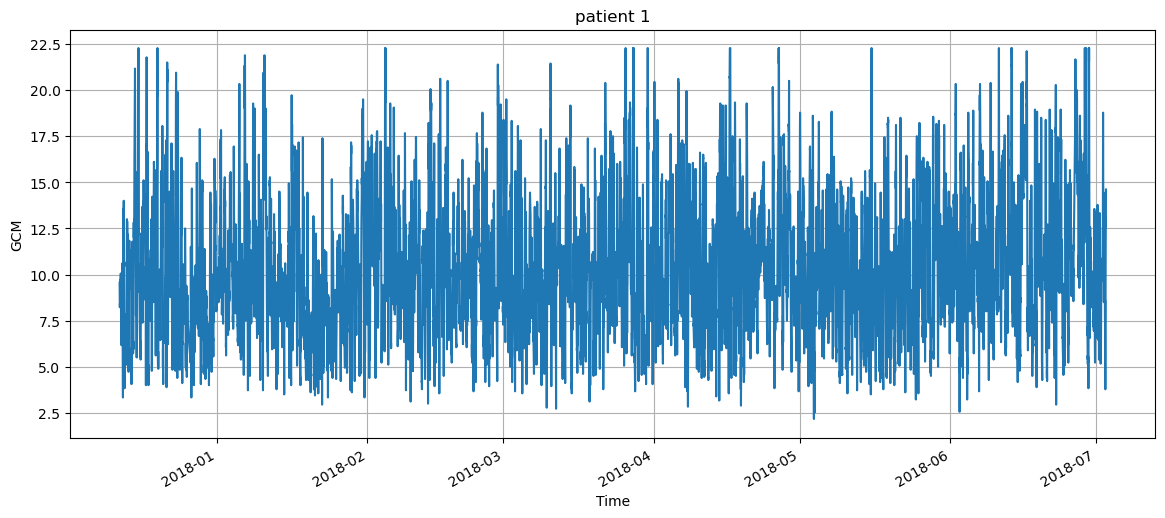

In [213]:
plt.figure(figsize=(14,6))
subset.plot(title="patient 1")
plt.xlabel("Time")
plt.ylabel("GCM")
plt.grid(True)
plt.show()

In [214]:
patient_id = 1
subset = dclp3[dclp3['PtID'] == patient_id].sort_values('DataDtTm')

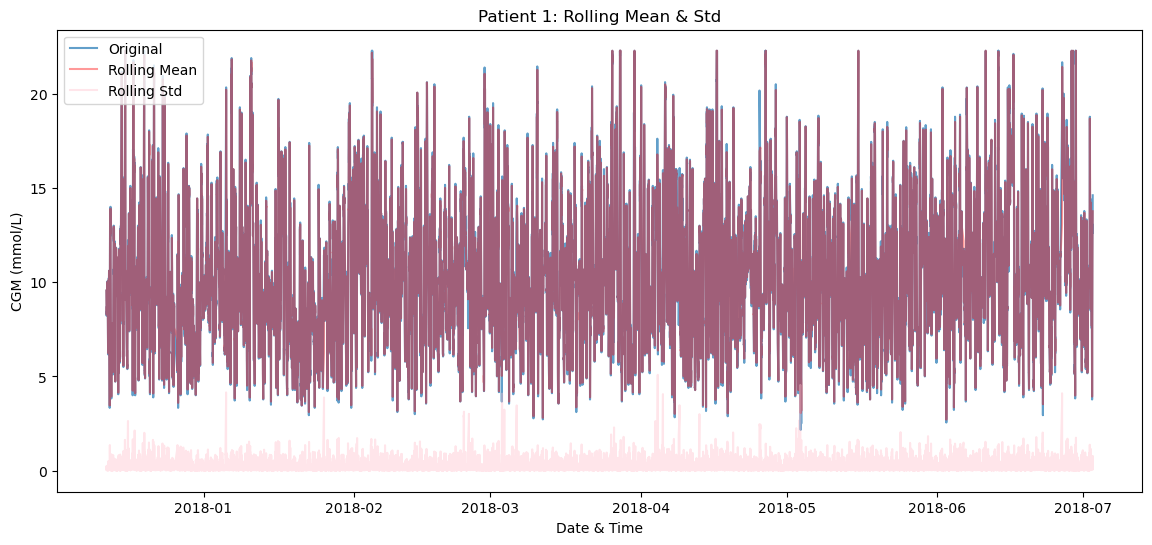

In [215]:
plt.figure(figsize=(14,6))
plt.plot(subset['DataDtTm'], subset['CGM_mmol'], label='Original', alpha=0.7)
plt.plot(subset['DataDtTm'], subset['rolling_mean_mmol'], label='Rolling Mean', color='red', alpha = 0.4)
plt.plot(subset['DataDtTm'], subset['rolling_std_mmol'], label='Rolling Std', color='pink', alpha = 0.4)
plt.legend()
plt.xlabel('Date & Time')
plt.ylabel('CGM (mmol/L)')
plt.title(f'Patient {patient_id}: Rolling Mean & Std')
plt.show()

In [216]:
patient_id = 1
subset = dclp3[dclp3['PtID'] == patient_id].sort_values('DataDtTm').copy()
subset = subset.set_index('DataDtTm')['CGM_mmol']
subset

DataDtTm
2017-12-11 23:59:25     9.555556
2017-12-12 00:04:24     9.444444
2017-12-12 00:09:24     9.277778
2017-12-12 00:14:25     9.055556
2017-12-12 00:19:25     8.888889
                         ...    
2018-07-02 23:37:32    12.611111
2018-07-02 23:42:33    12.888889
2018-07-02 23:47:33    13.444444
2018-07-02 23:52:32    14.111111
2018-07-02 23:57:33    14.611111
Name: CGM_mmol, Length: 57016, dtype: float64

#### ADF 1

In [217]:
# Stationary tests

# What does it mean if a dataset is stationary?
## mean & std are CONSTANT
## there is no seasonality

# H0: non-stationary
# H1: stationary
adf_result = adfuller(subset.dropna())
print('ADF statistic:', adf_result[0])
print('p-value:', adf_result[1]) # 0.0
# reject H0 --> H1 --> stationary

# H0: stationary
# H1: non-stationary
stat, p_value, lags, crit_values = kpss(subset, regression='c')  # 'c' = constant only
print('\nKPSS statistic:', stat)
print('p-value:', p_value) # 0.01
# reject H0 --> H1 --> non-stationary

ADF statistic: -24.81230182709697
p-value: 0.0

KPSS statistic: 1.7466827307445536
p-value: 0.01


C:\Users\meril\AppData\Local\Temp\ipykernel_19412\2013268461.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, crit_values = kpss(subset, regression='c')  # 'c' = constant only


If ADF says “stationary” and KPSS says “non-stationary,” this may indicate a slight trend or cyclicality that one test notices and the other does not.

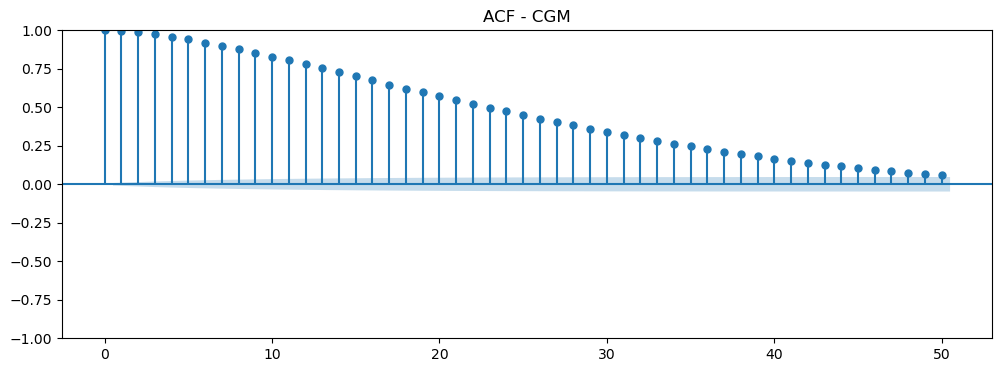

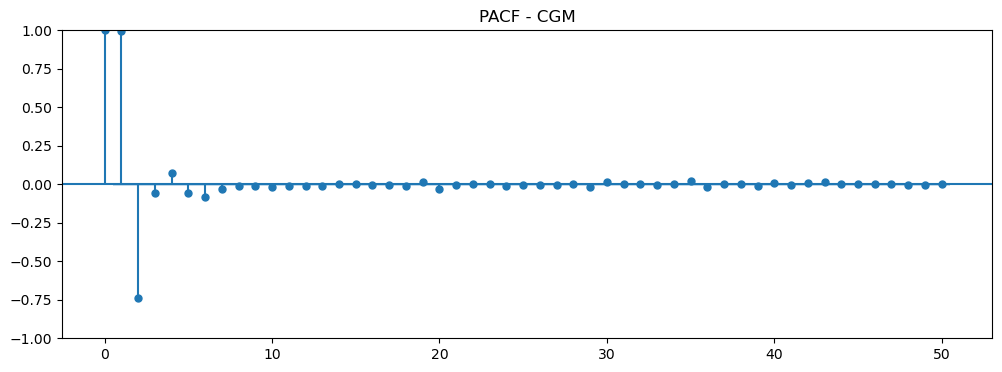

In [218]:
# ACF and PACF
plt.figure(figsize=(12,4))
plot_acf(subset.dropna(), lags=50, ax=plt.gca())
plt.title('ACF - CGM')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(subset.dropna(), lags=50, ax=plt.gca())
plt.title('PACF - CGM')
plt.show()

#### ADF 2 -- let's take the diff (difference)

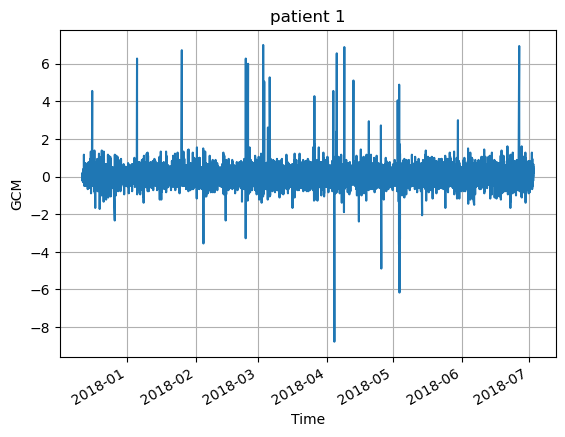

In [219]:
subset_diff = subset.diff().dropna()

subset_diff.plot(title="patient 1")
plt.xlabel("Time")
plt.ylabel("GCM")
plt.grid(True)
plt.show()

In [220]:
# H0: non-stationary
# H1: stationary
adf_result = adfuller(subset_diff)
print('ADF statistic:', adf_result[0])
print('p-value:', adf_result[1])
# H1 :(

# H0: stationary
# H1: non-stationary
kpss_result = kpss(subset_diff, regression='c')
print('\nKPSS statistic:', stat)
print('p-value:', p_value)
# H1 :(

ADF statistic: -40.058551296381864
p-value: 0.0

KPSS statistic: 1.7466827307445536
p-value: 0.01


C:\Users\meril\AppData\Local\Temp\ipykernel_19412\514452408.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(subset_diff, regression='c')


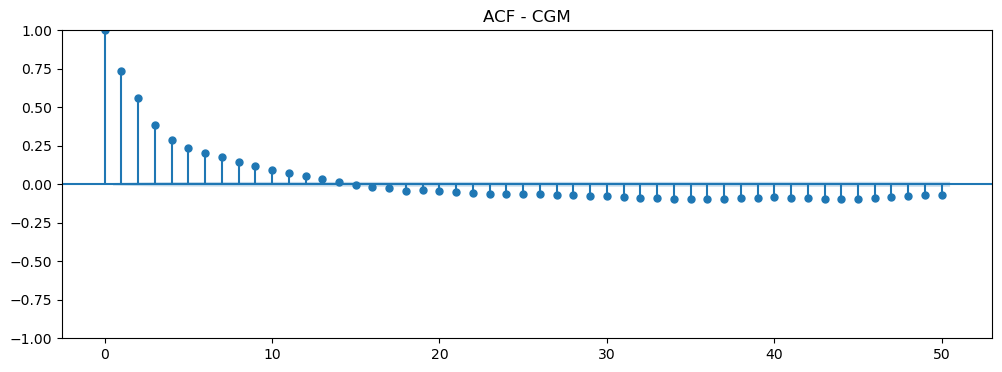

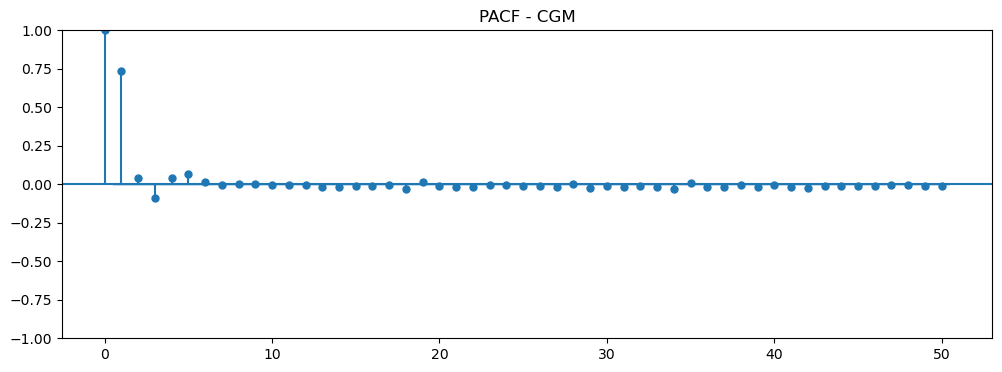

In [221]:
# ACF ja PACF
plt.figure(figsize=(12,4))
plot_acf(subset_diff.dropna(), lags=50, ax=plt.gca())
plt.title('ACF - CGM')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(subset_diff.dropna(), lags=50, ax=plt.gca())
plt.title('PACF - CGM')
plt.show()

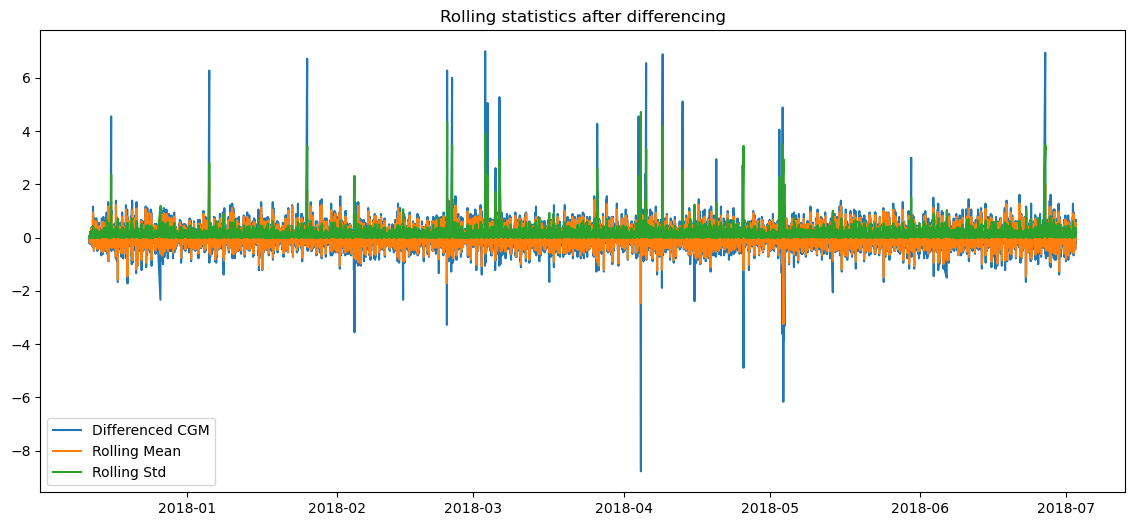

In [222]:
rolling_mean = subset_diff.rolling(window=4).mean()
rolling_std  = subset_diff.rolling(window=4).std()

plt.figure(figsize=(14,6))
plt.plot(subset_diff, label='Differenced CGM')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title('Rolling statistics after differencing')
plt.show()

#### ADF 3 (== ADF 1) -- standardising (z-score)

In [223]:
def diff_and_zscore(df):
    df = df.copy()
    df['CGM_diff'] = df['CGM_mmol'].diff()
    df['CGM_diff_z'] = (df['CGM_diff'] - df['CGM_diff'].mean()) / df['CGM_diff'].std()
    return df

In [224]:
dclp3_sorted = dclp3.sort_values(['PtID', 'DataDtTm'])

dclp3_processed = dclp3_sorted.groupby('PtID', group_keys=False).apply(diff_and_zscore).reset_index(drop=True)

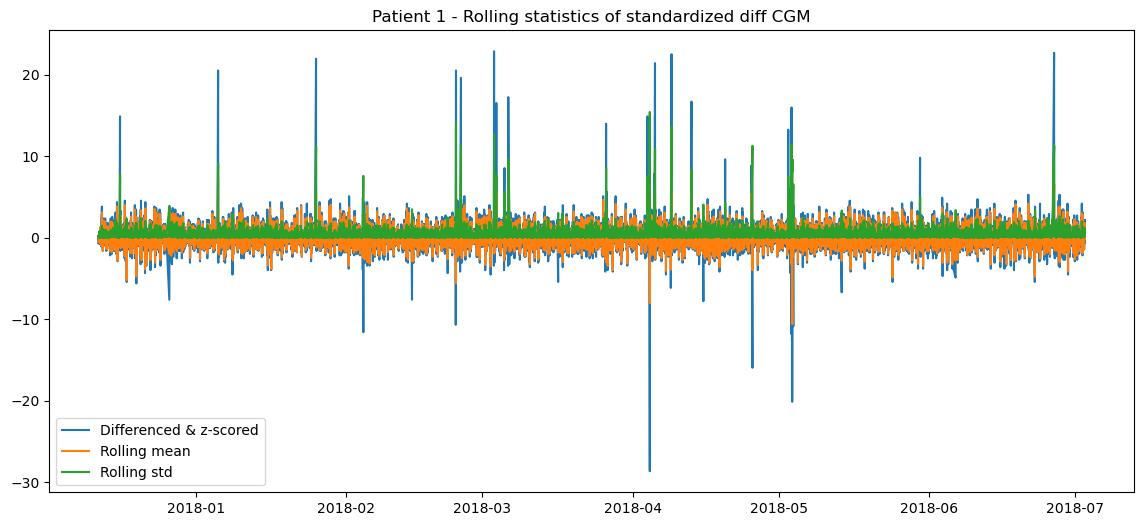

In [225]:
patient_id = 1
sub = dclp3_processed[dclp3_processed['PtID']==patient_id]

plt.figure(figsize=(14,6))
plt.plot(sub['DataDtTm'], sub['CGM_diff_z'], label='Differenced & z-scored')
plt.plot(sub['DataDtTm'], sub['CGM_diff_z'].rolling(window=4).mean(), label='Rolling mean')
plt.plot(sub['DataDtTm'], sub['CGM_diff_z'].rolling(window=4).std(), label='Rolling std')
plt.legend()
plt.title(f'Patient {patient_id} - Rolling statistics of standardized diff CGM')
plt.show()

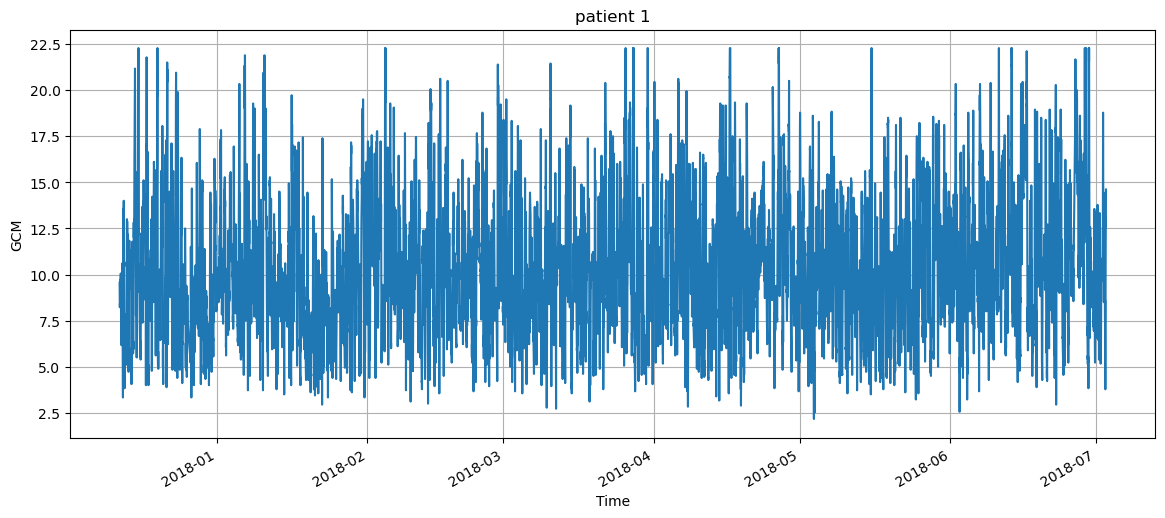

In [226]:
patient_id = 1
sub = dclp3_processed[dclp3_processed['PtID'] == patient_id].sort_values('DataDtTm').copy()
sub = sub.set_index('DataDtTm')['CGM_mmol']

plt.figure(figsize=(14,6))
sub.plot(title="patient 1")
plt.xlabel("Time")
plt.ylabel("GCM")
plt.grid(True)
plt.show()

In [227]:
# H0: non-stationary
# H1: stationary
adf_result = adfuller(sub)
print('ADF statistic:', adf_result[0])
print('p-value:', adf_result[1])
# H1 :(

# H0: stationary
# H1: non-stationary
kpss_result = kpss(sub, regression='c')
print('\nKPSS statistic:', stat)
print('p-value:', p_value)
# H1 :(

ADF statistic: -24.81230182709697
p-value: 0.0

KPSS statistic: 1.7466827307445536
p-value: 0.01


C:\Users\meril\AppData\Local\Temp\ipykernel_19412\50440243.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(sub, regression='c')


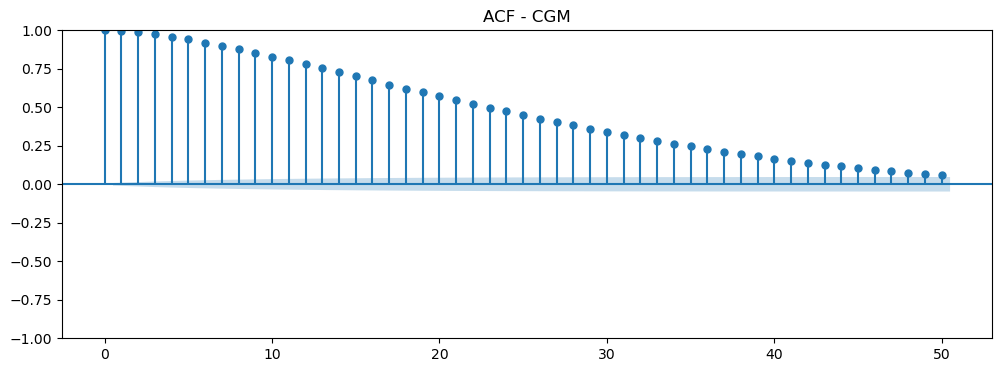

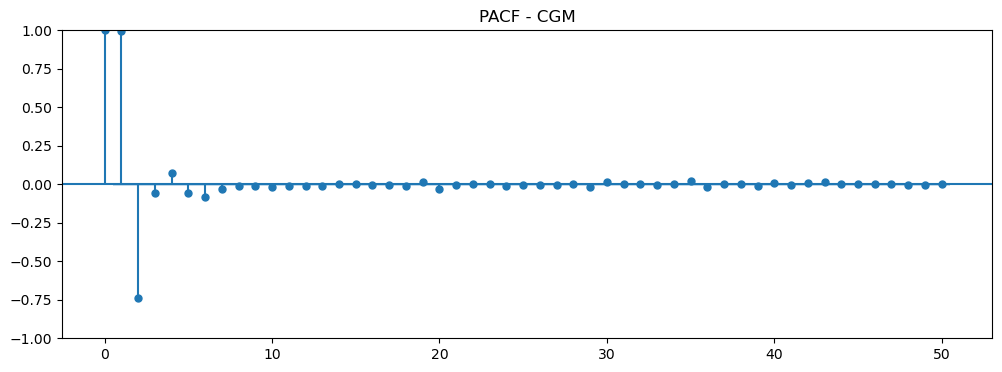

In [228]:
# ACF ja PACF
plt.figure(figsize=(12,4))
plot_acf(sub.dropna(), lags=50, ax=plt.gca())
plt.title('ACF - CGM')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(sub.dropna(), lags=50, ax=plt.gca())
plt.title('PACF - CGM')
plt.show()

### Strict pipeline

From patient selection to model evaluation.

In [35]:
overview[overview['PtID'] == 1]
overview[overview['PtID'].between(1, 1)]

,PtID,start_date,end_date,period_days
0,1,2017-12-11,2018-07-02,203


#### 1. Select the patient and extract their data.

In [36]:
pt = 1
df = dclp3[dclp3["PtID"] == pt].copy()
df["DataDtTm"] = pd.to_datetime(df["DataDtTm"])
df = df.sort_values("DataDtTm")
df = df.set_index(df["DataDtTm"], drop=False)

print(df.columns)

Index(['PtID', 'Period', 'DataDtTm', 'CGM', 'date', 'time', 'hour',
       'delta_min', 'time_period', 'CGM_mmol', 'in_range', 'CGM_category'],
      dtype='object')


#### 2. Check the continuity and regularity of time series

In [37]:
df["delta_min"] = df.index.to_series().diff().dt.total_seconds() / 60
df["delta_min"].describe()

count    57015.000000
mean         5.127039
std          6.075154
min          4.916667
25%          5.000000
50%          5.000000
75%          5.000000
max        859.966667
Name: delta_min, dtype: float64

Max 860 --> that's why SARIMA couldn't handle the 5-minute frequency

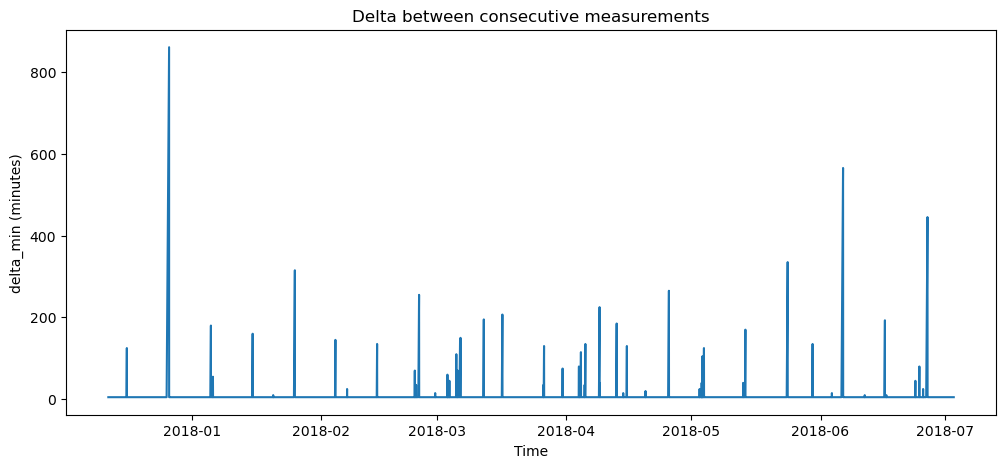

In [38]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["delta_min"])
plt.ylabel("delta_min (minutes)")
plt.xlabel("Time")
plt.title("Delta between consecutive measurements")
plt.show()

In [39]:
df = df.set_index("DataDtTm").resample("5min").ffill()

In [40]:
df.index = pd.DatetimeIndex(df.index, freq="5min")

In [41]:
df["delta_min"] = df.index.to_series().diff().dt.total_seconds() / 60
df["delta_min"].describe()

count    58464.0
mean         5.0
std          0.0
min          5.0
25%          5.0
50%          5.0
75%          5.0
max          5.0
Name: delta_min, dtype: float64

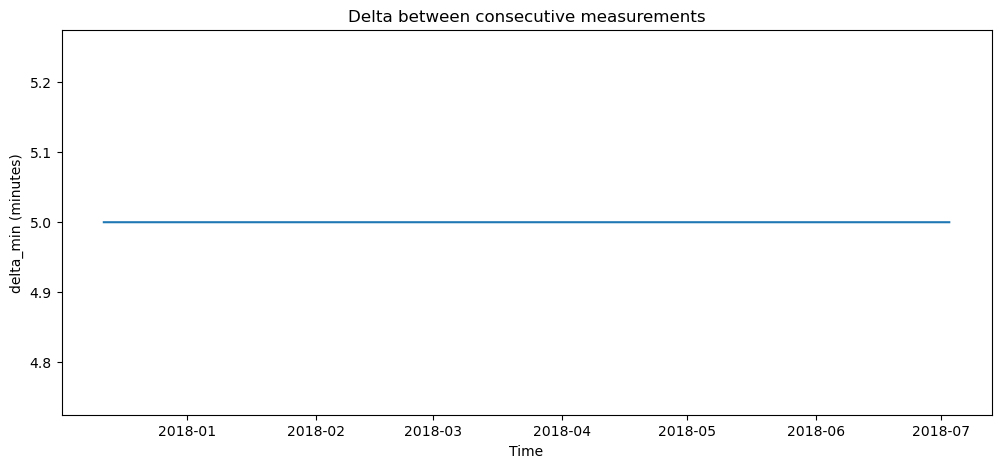

In [42]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["delta_min"])
plt.ylabel("delta_min (minutes)")
plt.xlabel("Time")
plt.title("Delta between consecutive measurements")
plt.show()

#### 3. Resample to regular 5-min bins

In [43]:
df_res = df["CGM_mmol"].resample("5min").mean()
df_res = df_res.interpolate()

#### 4. Check stationarity

<Axes: xlabel='DataDtTm'>

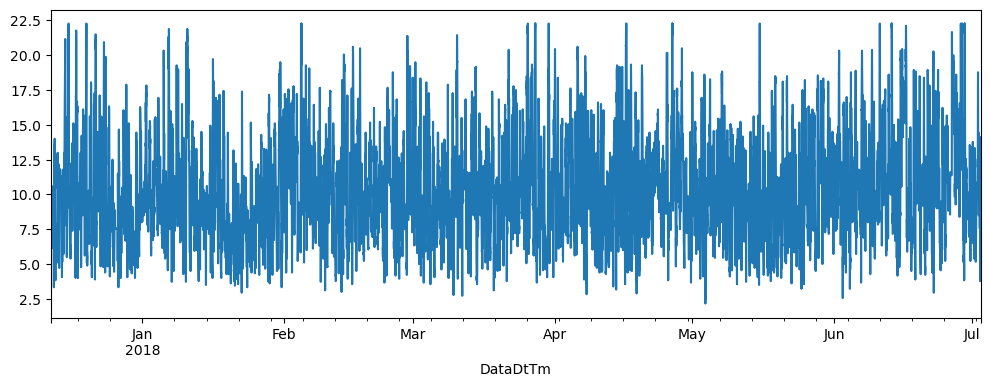

In [44]:
df_res.plot(figsize=(12,4))

In [45]:
# H0: non-stationary
# H1: stationary
adfuller(df_res.dropna())
# p << 0.05 --> H1 --> Stationary

(-24.541778109079228,
 0.0,
 53,
 58410,
 {'1%': -3.4304619600651525,
  '5%': -2.86158948420646,
  '10%': -2.5667963387791657},
 -23198.711287811544)

In [46]:
# 5. if not stationary
# df_diff = df_res.diff().dropna()

#### 6. Check seasonality

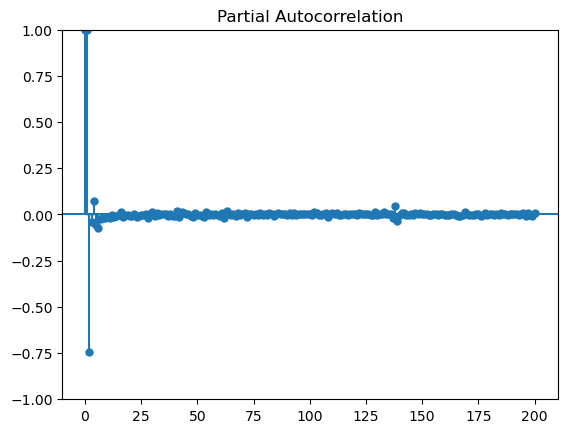

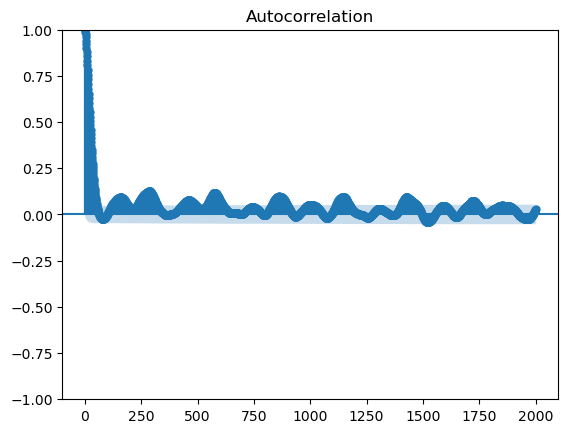

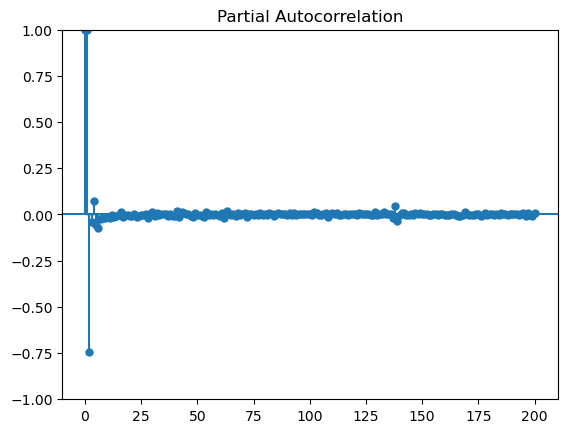

In [47]:
plot_acf(df_res.dropna(), lags=2000)
plot_pacf(df_res.dropna(), lags=200)

if ACF has peaks at every 288 steps → seasonality = 288

#### 7. Split into training and test data (test is 2 weeks)

In [49]:
train = df_res.iloc[:-288*14]
test  = df_res.iloc[-288*14:]
print(train)

DataDtTm
2017-12-11 23:55:00          NaN
2017-12-12 00:00:00     9.555556
2017-12-12 00:05:00     9.444444
2017-12-12 00:10:00     9.277778
2017-12-12 00:15:00     9.055556
                         ...    
2018-06-25 23:35:00    10.666667
2018-06-25 23:40:00    10.611111
2018-06-25 23:45:00    10.611111
2018-06-25 23:50:00    10.611111
2018-06-25 23:55:00    10.722222
Freq: 5min, Name: CGM_mmol, Length: 56449, dtype: float64


In [50]:
print(test)

DataDtTm
2018-06-19 00:00:00     9.555556
2018-06-19 00:05:00     9.333333
2018-06-19 00:10:00     9.333333
2018-06-19 00:15:00     9.833333
2018-06-19 00:20:00    10.555556
                         ...    
2018-07-02 23:35:00    12.722222
2018-07-02 23:40:00    12.611111
2018-07-02 23:45:00    12.888889
2018-07-02 23:50:00    13.444444
2018-07-02 23:55:00    14.111111
Freq: 5min, Name: CGM_mmol, Length: 4032, dtype: float64


### BEST 60-min bins, 2 week splits, RMSE = 3.651

In [138]:
train_hourly = train.resample("1h").mean()
seasonal_order=(1,1,1,24)

In [139]:
model = SARIMAX(
    train_hourly,
    order=(1,1,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [140]:
start = time()
res = model.fit(disp=False)
end = time()
print('Model Fitting Time:', end - start)
# Model Fitting Time: 85.2

Model Fitting Time: 85.17925310134888


#### 9. Model diagnostics

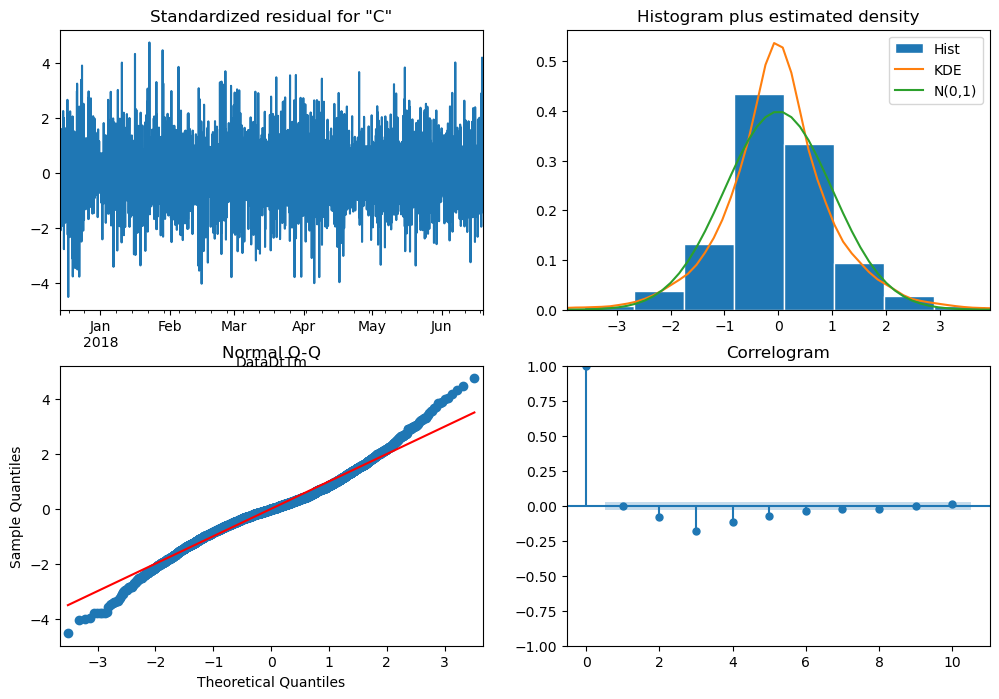

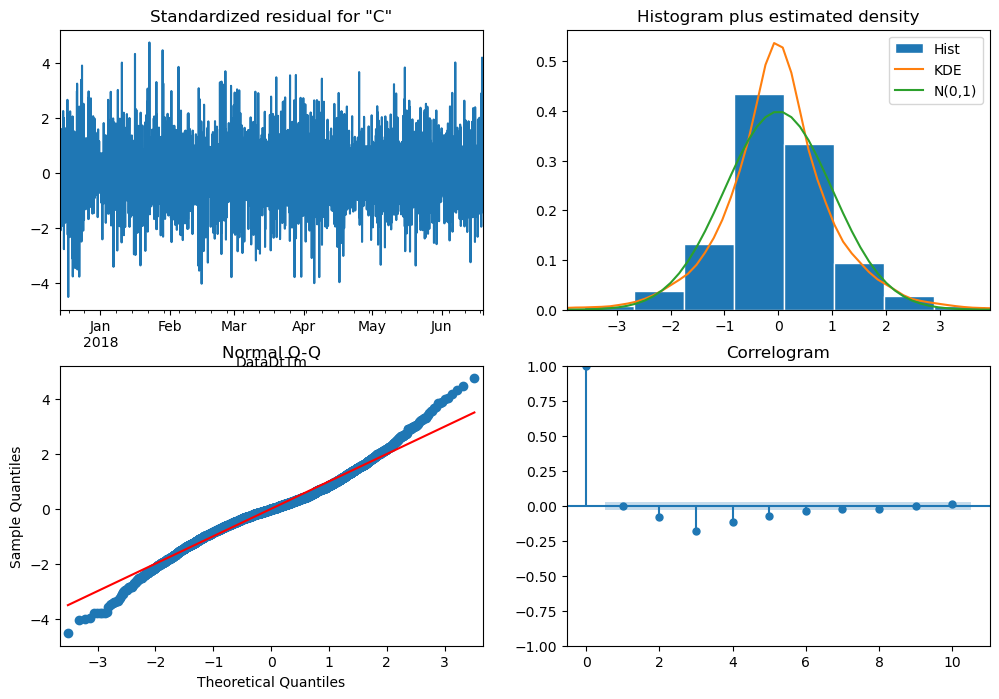

In [141]:
res.plot_diagnostics(figsize=(12,8))

* are the residuals white noise?

* is the Q-Q plot normal?

* does the ACF plot in the residuals show that something has been left unmodeled?

If not → change P,Q or p,q.

#### 10. Forecast for the train --> test period

In [142]:
test_hourly = test.resample("1h").mean()

pred = res.get_forecast(steps=len(test_hourly))
pred_mean = pred.predicted_mean
pred_conf = pred.conf_int()

#### 11. Plot

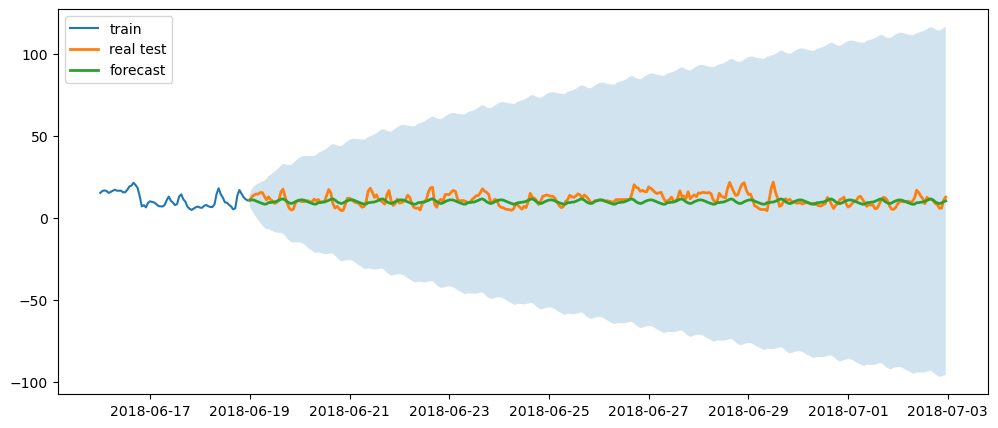

In [143]:
plt.figure(figsize=(12,5))
plt.plot(train_hourly[-24*3:], label="train")       # last 3 days of hourly data
plt.plot(test_hourly, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)
plt.fill_between(pred_conf.index,
                 pred_conf.iloc[:,0],
                 pred_conf.iloc[:,1],
                 alpha=0.2)
plt.legend()

#### 12. Calculate prediction accuracy

In [144]:
mae = mean_absolute_error(test_hourly, pred_mean)
rmse = np.sqrt(mean_squared_error(test_hourly, pred_mean))

mae, rmse
# (2.853313925065505, 3.6509920172475394)

(2.853313925065505, 3.6509920172475394)

If:
* RMSE ~1 mmol → very good
* RMSE ~2–3 mmol → OK
* RMSE >4 mmol → model weak → need better p,d,q or P,D,Q

### 3RD BEST 60-min bins, 1 week splits, RMSE = 4.121

In [52]:
train = df_res.iloc[:-288*7]
test  = df_res.iloc[-288*7:]
print(train)

DataDtTm
2017-12-11 23:55:00          NaN
2017-12-12 00:00:00     9.555556
2017-12-12 00:05:00     9.444444
2017-12-12 00:10:00     9.277778
2017-12-12 00:15:00     9.055556
                         ...    
2018-06-25 23:35:00    10.666667
2018-06-25 23:40:00    10.611111
2018-06-25 23:45:00    10.611111
2018-06-25 23:50:00    10.611111
2018-06-25 23:55:00    10.722222
Freq: 5min, Name: CGM_mmol, Length: 56449, dtype: float64


In [51]:
print(test)

DataDtTm
2018-06-26 00:00:00    10.833333
2018-06-26 00:05:00    10.944444
2018-06-26 00:10:00    11.055556
2018-06-26 00:15:00    11.055556
2018-06-26 00:20:00    11.000000
                         ...    
2018-07-02 23:35:00    12.722222
2018-07-02 23:40:00    12.611111
2018-07-02 23:45:00    12.888889
2018-07-02 23:50:00    13.444444
2018-07-02 23:55:00    14.111111
Freq: 5min, Name: CGM_mmol, Length: 2016, dtype: float64


In [53]:
train_hourly = train.resample("1h").mean()

In [54]:
model = SARIMAX(
    train_hourly,
    order=(1,1,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [55]:
start = time()
res = model.fit(disp=False)
end = time()
print('Model Fitting Time:', end - start)
# Model Fitting Time: 63.35690975189209

Model Fitting Time: 63.35690975189209


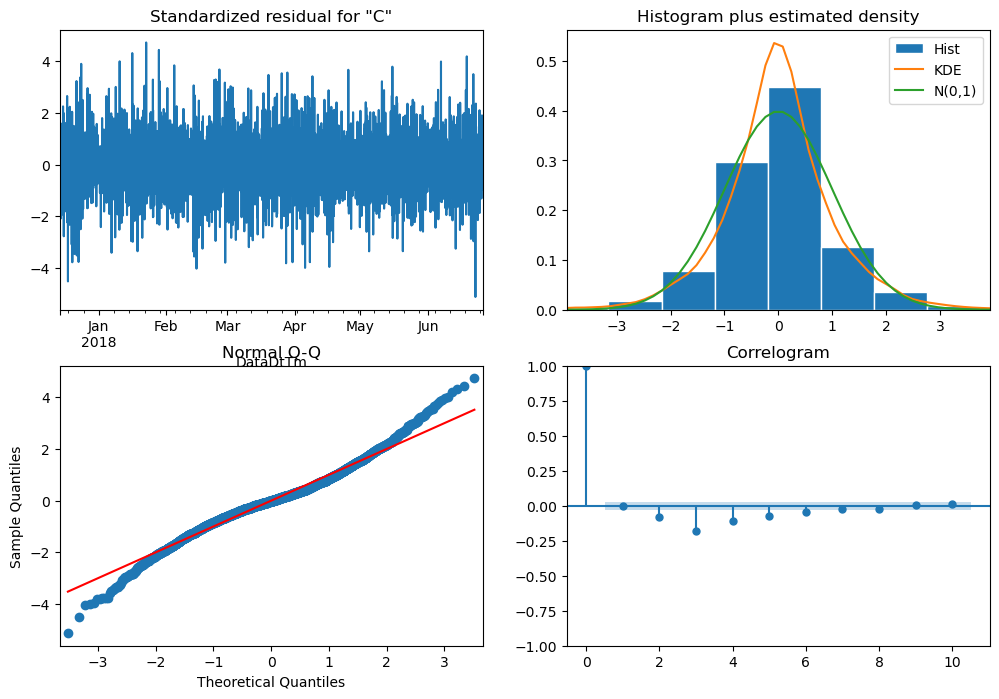

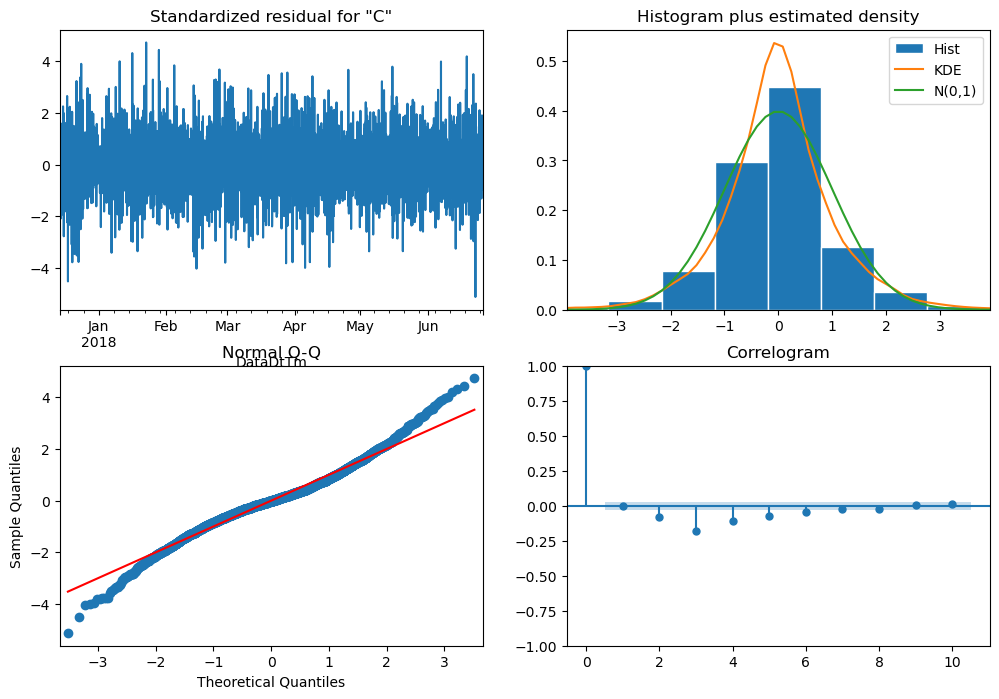

In [56]:
res.plot_diagnostics(figsize=(12,8))

In [57]:
test_hourly = test.resample("1h").mean()

pred = res.get_forecast(steps=len(test_hourly))
pred_mean = pred.predicted_mean
pred_conf = pred.conf_int()

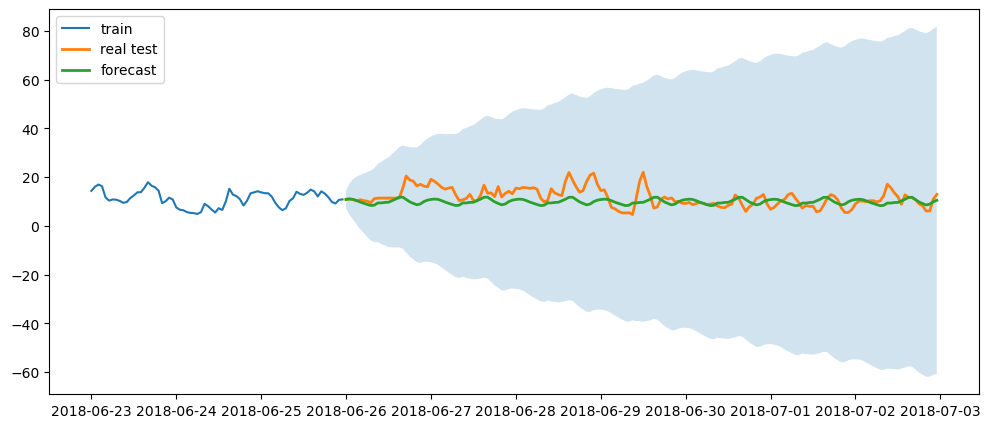

In [58]:
plt.figure(figsize=(12,5))
plt.plot(train_hourly[-24*3:], label="train")       # last 3 days of hourly data
plt.plot(test_hourly, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)
plt.fill_between(pred_conf.index,
                 pred_conf.iloc[:,0],
                 pred_conf.iloc[:,1],
                 alpha=0.2)
plt.legend()

In [59]:
mae = mean_absolute_error(test_hourly, pred_mean)
rmse = np.sqrt(mean_squared_error(test_hourly, pred_mean))

mae, rmse
# (3.159297958251913, 4.121065138798688)

(3.159297958251913, 4.121065138798688)

### MemoryError. batching: 15-min bins, 2 week splits

### batching: 15-min bins, 1 week splits, RMSE = 4.7346

In [114]:
train = df_res.iloc[:-288*7]
test  = df_res.iloc[-288*7:]

In [115]:
train_15min = train.resample("15min").mean()
test_15min = test.resample("15min").mean()

In [116]:
batch_size = 96*7  # 96 points = 1 day, 7 days total = 1 week
values = train_15min.values
n = len(values)

batches = [
    values[i:i+batch_size] 
    for i in range(0, n, batch_size)
]

In [117]:
for idx, b in enumerate(batches):
    print(idx, len(b))

0 672
1 672
2 672
3 672
4 672
5 672
6 672
7 672
8 672
9 672
10 672
11 672
12 672
13 672
14 672
15 672
16 672
17 672
18 672
19 672
20 672
21 672
22 672
23 672
24 672
25 672
26 672
27 672
28 1


In [118]:
batches = [b for b in batches if len(b) >= 50]  # or at least 48

In [119]:
for idx, b in enumerate(batches):
    print(idx, len(b))

0 672
1 672
2 672
3 672
4 672
5 672
6 672
7 672
8 672
9 672
10 672
11 672
12 672
13 672
14 672
15 672
16 672
17 672
18 672
19 672
20 672
21 672
22 672
23 672
24 672
25 672
26 672
27 672


In [120]:
initial_batch = batches[0]

model = SARIMAX(
    initial_batch,
    order=(1,1,1),
    seasonal_order=(1,1,1,96),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [121]:
start = time()
res = model.fit(disp=False)
end = time()
print("Done batch 1")
print('Model Fitting Time:', end - start)

# 166.5 s

Done batch 1
Model Fitting Time: 166.4953269958496


In [122]:
for b in range(1, len(batches)):
    batch = batches[b]
    
    model = SARIMAX(
        batch,
        order=(1,1,1),
        seasonal_order=(1,1,1,96),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    # the model starts optimization from the parameters of the previous batch
    start = time()
    res = model.fit(start_params=res.params, disp=False)
    end = time()
    print('Model Fitting Time:', end - start)
    print(f"Done batch {b+1} / {len(batches)}")

# 4413.34 s, 73.56 min


######## When the batches were by 2 weeks ##########################
# Model Fitting Time: 342.4171097278595
#Done batch 2 / 13
#Model Fitting Time: 247.03835344314575
#Done batch 3 / 13
#Model Fitting Time: 298.57684206962585
#Done batch 4 / 13
#Model Fitting Time: 240.9571976661682
#Done batch 5 / 13
# MemoryError: Unable to allocate 390. MiB for an array with shape (195, 195, 1344) and data type float64

Model Fitting Time: 277.658310174942
Done batch 2 / 27
Model Fitting Time: 291.4817099571228
Done batch 3 / 27
Model Fitting Time: 201.4827229976654
Done batch 4 / 27
Model Fitting Time: 158.24437761306763
Done batch 5 / 27
Model Fitting Time: 128.72107100486755
Done batch 6 / 27
Model Fitting Time: 157.7756862640381
Done batch 7 / 27
Model Fitting Time: 143.30468440055847
Done batch 8 / 27
Model Fitting Time: 158.48815035820007
Done batch 9 / 27
Model Fitting Time: 148.79624390602112
Done batch 10 / 27
Model Fitting Time: 163.12803316116333
Done batch 11 / 27
Model Fitting Time: 220.35862708091736
Done batch 12 / 27
Model Fitting Time: 148.8738570213318
Done batch 13 / 27
Model Fitting Time: 142.9328737258911
Done batch 14 / 27
Model Fitting Time: 123.68527173995972
Done batch 15 / 27
Model Fitting Time: 142.0172519683838
Done batch 16 / 27
Model Fitting Time: 135.53015184402466
Done batch 17 / 27
Model Fitting Time: 128.16908812522888
Done batch 18 / 27
Model Fitting Time: 141.300800

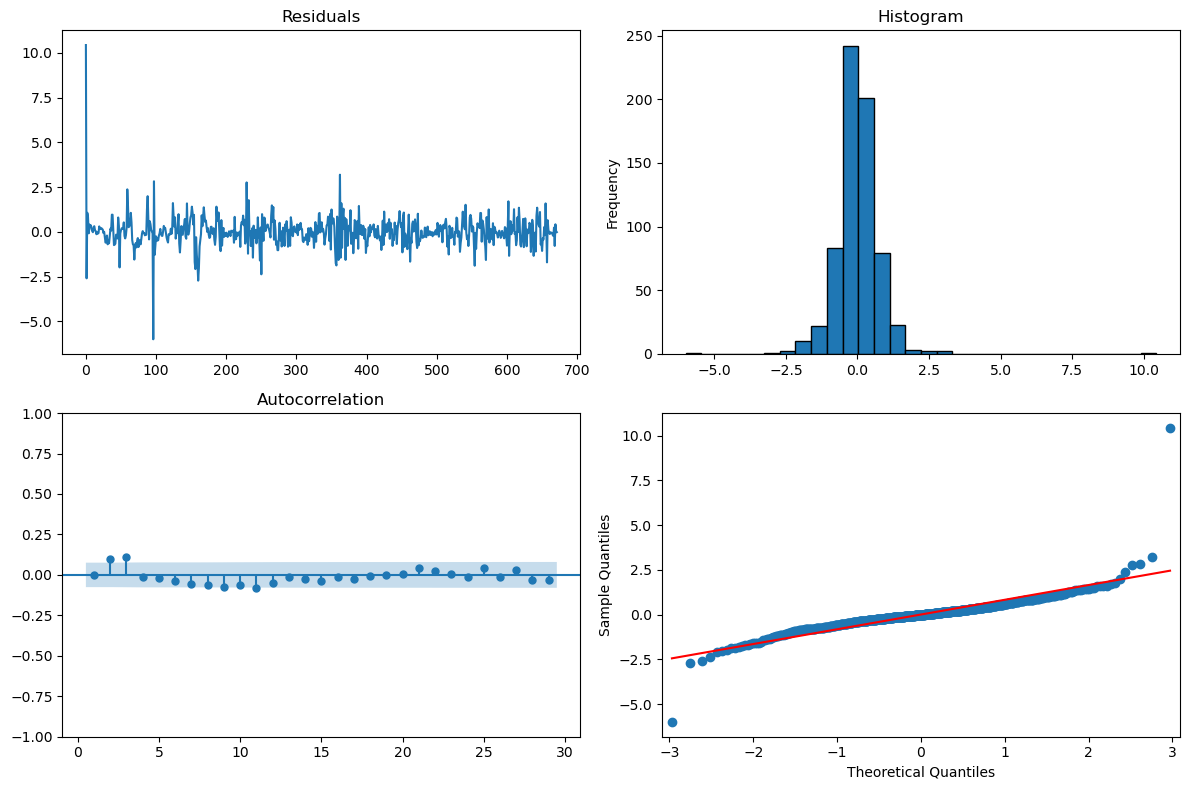

In [124]:
residuals = pd.Series(res.resid)

fig, ax = plt.subplots(2,2,figsize=(12,8))

# Residuals in time
ax[0,0].plot(residuals)
ax[0,0].set_title("Residuals")

# Histogram
residuals.plot(kind='hist', bins=30, ax=ax[0,1], edgecolor='black')
ax[0,1].set_title("Histogram")

# ACF
plot_acf(residuals.dropna(), ax=ax[1,0], zero=False)

# QQ-plot
sm.qqplot(residuals.dropna(), line="s", ax=ax[1,1])

plt.tight_layout()
plt.show()

In [131]:
forecast_steps = len(test_15min)
forecast_res = res.get_forecast(steps=forecast_steps)
pred_mean = forecast_res.predicted_mean
pred_conf = forecast_res.conf_int()

In [132]:
# Expect that test_15min is a pandas series with proper datetime index
forecast_index = test_15min.index

# numpy → pandas
pred_mean = pd.Series(pred_mean, index=forecast_index)
pred_conf = pd.DataFrame(pred_conf, index=forecast_index, columns=["lower", "upper"])

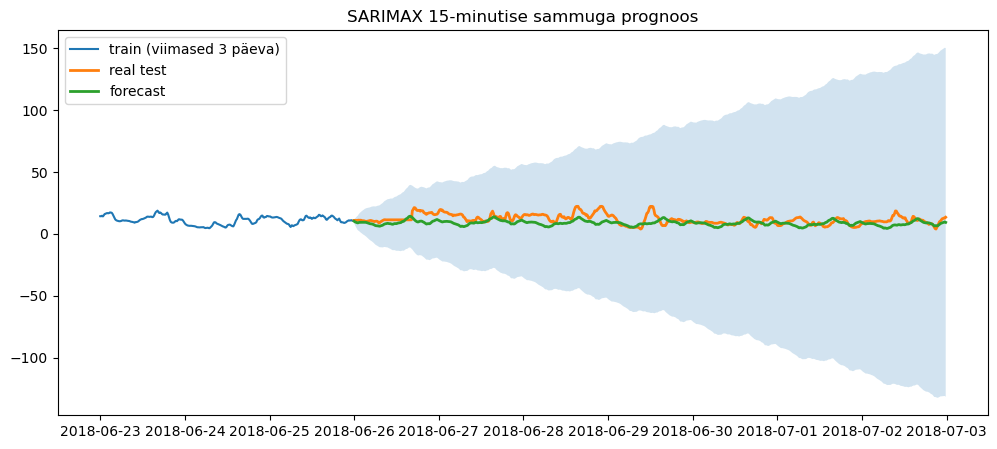

In [133]:
plt.figure(figsize=(12,5))
plt.plot(train_15min[-96*3:], label="train (last 3 days)")
plt.plot(test_15min, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)
plt.fill_between(pred_conf.index,
                 pred_conf.iloc[:,0],
                 pred_conf.iloc[:,1],
                 alpha=0.2)
plt.legend()
plt.title("SARIMAX 15-min bin forecast")
plt.show()

In [136]:
mae = mean_absolute_error(test_15min, pred_mean)
rmse = np.sqrt(mean_squared_error(test_15min, pred_mean))

mae, rmse
# (3.6895041165204505, 4.734635110505781)

(3.6895041165204505, 4.734635110505781)

### batching: 30-min bins, 2 week splits, RMSE = 5.356

In [ ]:
train = df_res.iloc[:-288*14]
test  = df_res.iloc[-288*14:]

In [145]:
train_30min = train.resample("30min").mean()
test_30min = test.resample("30min").mean()

In [146]:
batch_size = 48*14  # 48 points = 1 day, 14 days total = 2 weeks
values = train_30min.values
n = len(values)

batches = [
    values[i:i+batch_size] 
    for i in range(0, n, batch_size)
]

In [147]:
len(batches)

14

In [148]:
initial_batch = batches[0]

model = SARIMAX(
    initial_batch,
    order=(1,1,1),
    seasonal_order=(1,1,1,48),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [149]:
start = time()
res = model.fit(disp=False)
end = time()
print("Done batch 1")
print('Model Fitting Time:', end - start)
# 73.274 s

Done batch 1
Model Fitting Time: 73.27416801452637


In [150]:
for b in range(1, len(batches)):
    batch = batches[b]
    
    model = SARIMAX(
        batch,
        order=(1,1,1),
        seasonal_order=(1,1,1,48),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    # the model starts optimization from the parameters of the previous batch
    start = time()
    res = model.fit(start_params=res.params, disp=False)
    end = time()
    print('Model Fitting Time:', end - start)
    print(f"Done batch {b+1} / {len(batches)}")


# MODEL FITTING TIME: 628.07 s (10.47 min)

Model Fitting Time: 20.93264365196228
Done batch 2 / 14
Model Fitting Time: 21.563124179840088
Done batch 3 / 14
Model Fitting Time: 22.034746646881104
Done batch 4 / 14
Model Fitting Time: 19.509013891220093
Done batch 5 / 14
Model Fitting Time: 22.960301399230957
Done batch 6 / 14
Model Fitting Time: 24.442403316497803
Done batch 7 / 14
Model Fitting Time: 43.330888986587524
Done batch 8 / 14
Model Fitting Time: 51.07415175437927
Done batch 9 / 14
Model Fitting Time: 70.89920020103455
Done batch 10 / 14
Model Fitting Time: 51.27151155471802
Done batch 11 / 14
Model Fitting Time: 70.57200932502747
Done batch 12 / 14
Model Fitting Time: 83.49684953689575
Done batch 13 / 14
Model Fitting Time: 33.70660996437073
Done batch 14 / 14


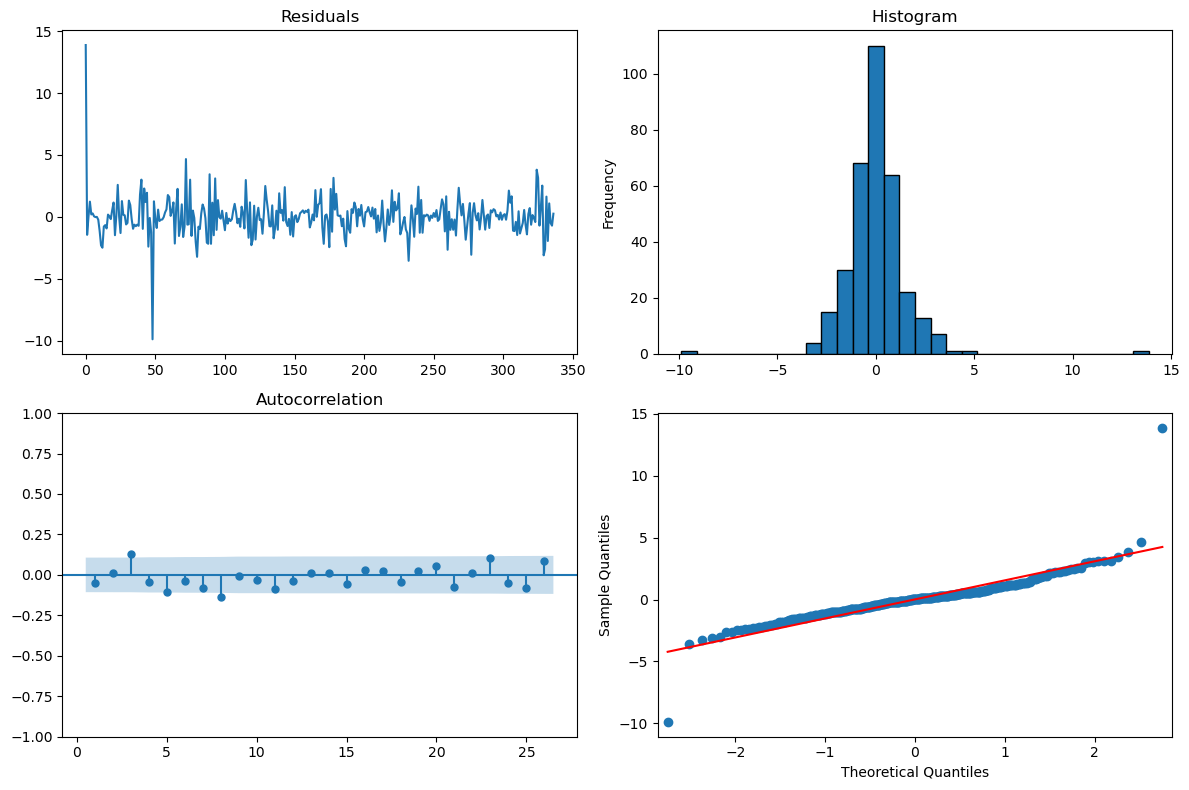

In [151]:
residuals = pd.Series(res.resid)

fig, ax = plt.subplots(2,2,figsize=(12,8))

# Residuals in time
ax[0,0].plot(residuals)
ax[0,0].set_title("Residuals")

# Histogram
residuals.plot(kind='hist', bins=30, ax=ax[0,1], edgecolor='black')
ax[0,1].set_title("Histogram")

# ACF
plot_acf(residuals.dropna(), ax=ax[1,0], zero=False)

# QQ-plot
sm.qqplot(residuals.dropna(), line="s", ax=ax[1,1])

plt.tight_layout()
plt.show()

In [156]:
forecast_steps = len(test_30min)
forecast_res = res.get_forecast(steps=forecast_steps)
pred_mean = forecast_res.predicted_mean
pred_conf = forecast_res.conf_int()

In [157]:
# Expect that test_30min is a pandas series with proper datetime index
forecast_index = test_30min.index

# numpy → pandas
pred_mean = pd.Series(pred_mean, index=forecast_index)
pred_conf = pd.DataFrame(pred_conf, index=forecast_index, columns=["lower", "upper"])

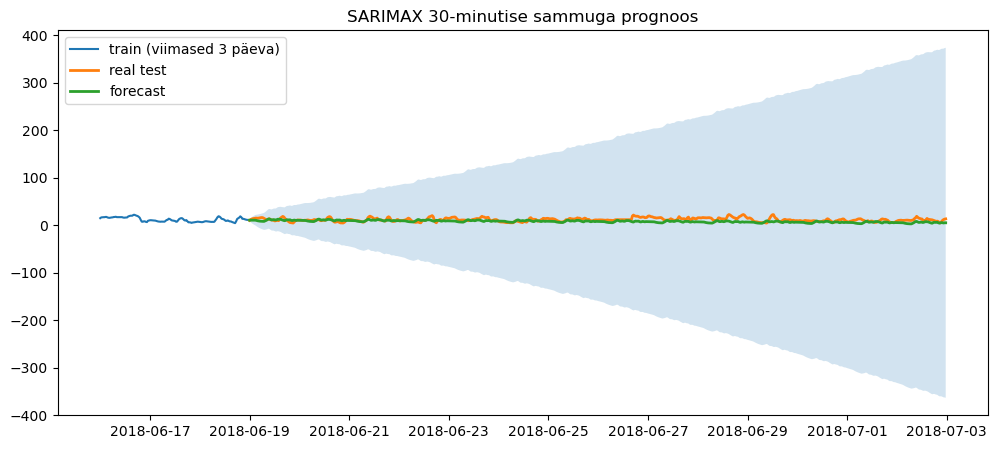

In [158]:
plt.figure(figsize=(12,5))
plt.plot(train_30min[-48*3:], label="train (last 3 päevdaysa)")
plt.plot(test_30min, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)

plt.fill_between(
    pred_conf.index,
    pred_conf["lower"],
    pred_conf["upper"],
    alpha=0.2
)

plt.legend()
plt.title("SARIMAX 30-bin forecast")
plt.show()

In [159]:
mae = mean_absolute_error(test_30min, pred_mean)
rmse = np.sqrt(mean_squared_error(test_30min, pred_mean))

mae, rmse
# (4.287240058693572, 5.356153312562148)

(4.287240058693572, 5.356153312562148)

### batching: 30-min bins, 1 week splits, RMSE = 5.663

In [74]:
train = df_res.iloc[:-288*7]
test  = df_res.iloc[-288*7:]

In [75]:
train_30min = train.resample("30min").mean()
test_30min = test.resample("30min").mean()

In [79]:
batch_size = 48*7  # 48 points = 1 day, total 7 days = 1 week
values = train_30min.values
n = len(values)

batches = [
    values[i:i+batch_size] 
    for i in range(0, n, batch_size)
]

In [80]:
for idx, b in enumerate(batches):
    print(idx, len(b))

0 336
1 336
2 336
3 336
4 336
5 336
6 336
7 336
8 336
9 336
10 336
11 336
12 336
13 336
14 336
15 336
16 336
17 336
18 336
19 336
20 336
21 336
22 336
23 336
24 336
25 336
26 336
27 336
28 1


In [81]:
batches = [b for b in batches if len(b) >= 50]

In [82]:
for idx, b in enumerate(batches):
    print(idx, len(b))

0 336
1 336
2 336
3 336
4 336
5 336
6 336
7 336
8 336
9 336
10 336
11 336
12 336
13 336
14 336
15 336
16 336
17 336
18 336
19 336
20 336
21 336
22 336
23 336
24 336
25 336
26 336
27 336


In [83]:
initial_batch = batches[0]

model = SARIMAX(
    initial_batch,
    order=(1,1,1),
    seasonal_order=(1,1,1,48),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [84]:
start = time()
res = model.fit(disp=False)
end = time()
print("Done batch 1")
print('Model Fitting Time:', end - start)

Done batch 1
Model Fitting Time: 11.730929136276245


In [85]:
for b in range(1, len(batches)):
    batch = batches[b]
    
    model = SARIMAX(
        batch,
        order=(1,1,1),
        seasonal_order=(1,1,1,48),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    start = time()
    res = model.fit(start_params=res.params, disp=False)
    end = time()
    print('Model Fitting Time:', end - start)
    print(f"Done batch {b+1} / {len(batches)}")

# ≈ 338.70 s,  5.65 min

Model Fitting Time: 13.627603769302368
Done batch 2 / 28
Model Fitting Time: 12.71371865272522
Done batch 3 / 28
Model Fitting Time: 12.077739477157593
Done batch 4 / 28
Model Fitting Time: 14.440029859542847
Done batch 5 / 28
Model Fitting Time: 10.34343957901001
Done batch 6 / 28
Model Fitting Time: 12.718337535858154
Done batch 7 / 28
Model Fitting Time: 11.994714260101318
Done batch 8 / 28
Model Fitting Time: 12.409005880355835
Done batch 9 / 28
Model Fitting Time: 10.542725324630737
Done batch 10 / 28
Model Fitting Time: 12.3931245803833
Done batch 11 / 28
Model Fitting Time: 12.770249605178833
Done batch 12 / 28
Model Fitting Time: 12.498032093048096
Done batch 13 / 28
Model Fitting Time: 10.2288658618927
Done batch 14 / 28
Model Fitting Time: 12.239327430725098
Done batch 15 / 28
Model Fitting Time: 12.016822814941406
Done batch 16 / 28
Model Fitting Time: 10.623879194259644
Done batch 17 / 28
Model Fitting Time: 11.347193002700806
Done batch 18 / 28
Model Fitting Time: 12.46763

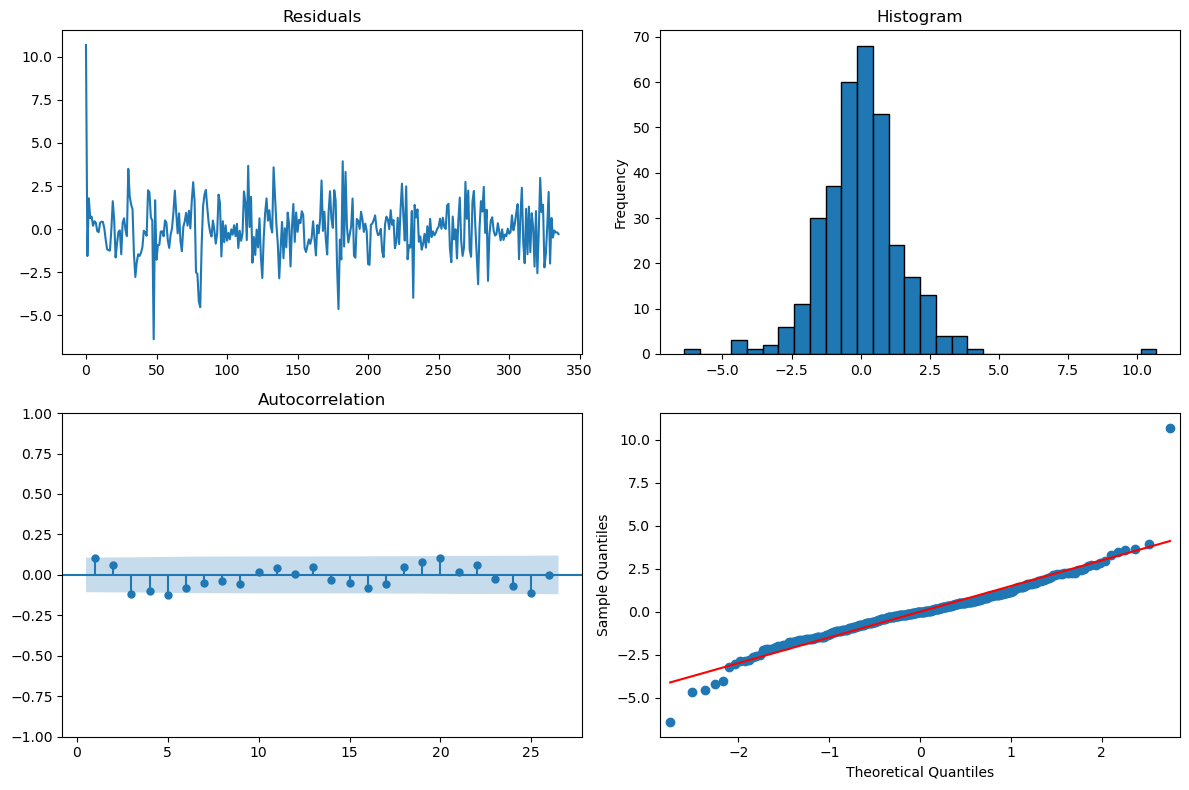

In [88]:
residuals = pd.Series(res.resid)

fig, ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].plot(residuals)
ax[0,0].set_title("Residuals")

# Histogram
residuals.plot(kind='hist', bins=30, ax=ax[0,1], edgecolor='black')
ax[0,1].set_title("Histogram")

# ACF
plot_acf(residuals.dropna(), ax=ax[1,0], zero=False)

# QQ-plot
sm.qqplot(residuals.dropna(), line="s", ax=ax[1,1])

plt.tight_layout()
plt.show()

In [89]:
forecast_steps = len(test_30min)
forecast_res = res.get_forecast(steps=forecast_steps)
pred_mean = forecast_res.predicted_mean
pred_conf = forecast_res.conf_int()

In [90]:
forecast_index = test_30min.index

# numpy → pandas
pred_mean = pd.Series(pred_mean, index=forecast_index)
pred_conf = pd.DataFrame(pred_conf, index=forecast_index, columns=["lower", "upper"])

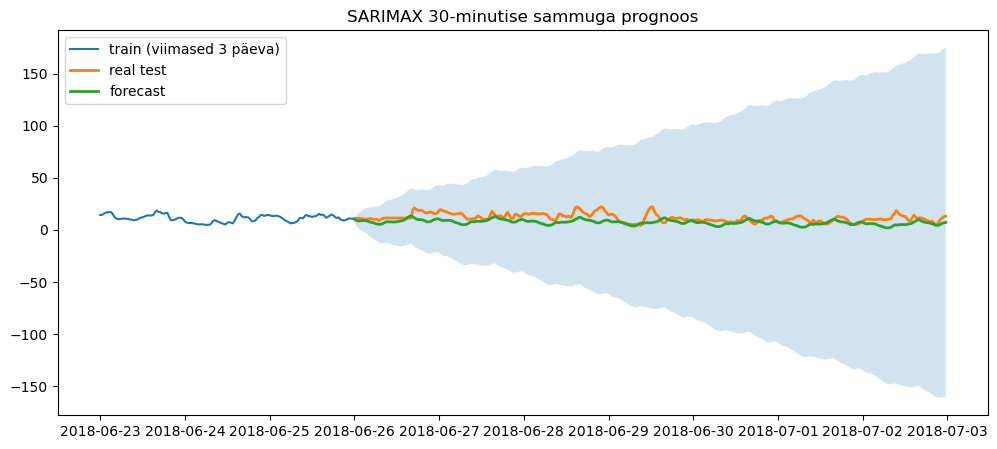

In [91]:
plt.figure(figsize=(12,5))
plt.plot(train_30min[-48*3:], label="train (last 3 days)")
plt.plot(test_30min, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)

plt.fill_between(
    pred_conf.index,
    pred_conf["lower"],
    pred_conf["upper"],
    alpha=0.2
)

plt.legend()
plt.title("SARIMAX 30-bin forecast")
plt.show()

In [92]:
mae = mean_absolute_error(test_30min, pred_mean)
rmse = np.sqrt(mean_squared_error(test_30min, pred_mean))

mae, rmse
# (4.655498127347328, 5.663701456163328)

(4.655498127347328, 5.663701456163328)

### 2ND BEST 30-min bins, 2 week split, RMSE = 3.9235

In [ ]:
train = df_res.iloc[:-288*14]
test  = df_res.iloc[-288*14:]

In [114]:
train_30min = train.resample("30min").mean()
test_30min  = test.resample("30min").mean()

In [87]:
model_30min = SARIMAX(
    train_30min,
    order=(1,1,1),
    seasonal_order=(1,1,1,48),
    simple_differencing=False,
    enforce_stationarity=True,
    enforce_invertibility=True
)

In [88]:
start = time()
res = model_30min.fit(disp=False)
end = time()
print('Model Fitting Time:', end - start)

# 341 s

Model Fitting Time: 341.56743144989014


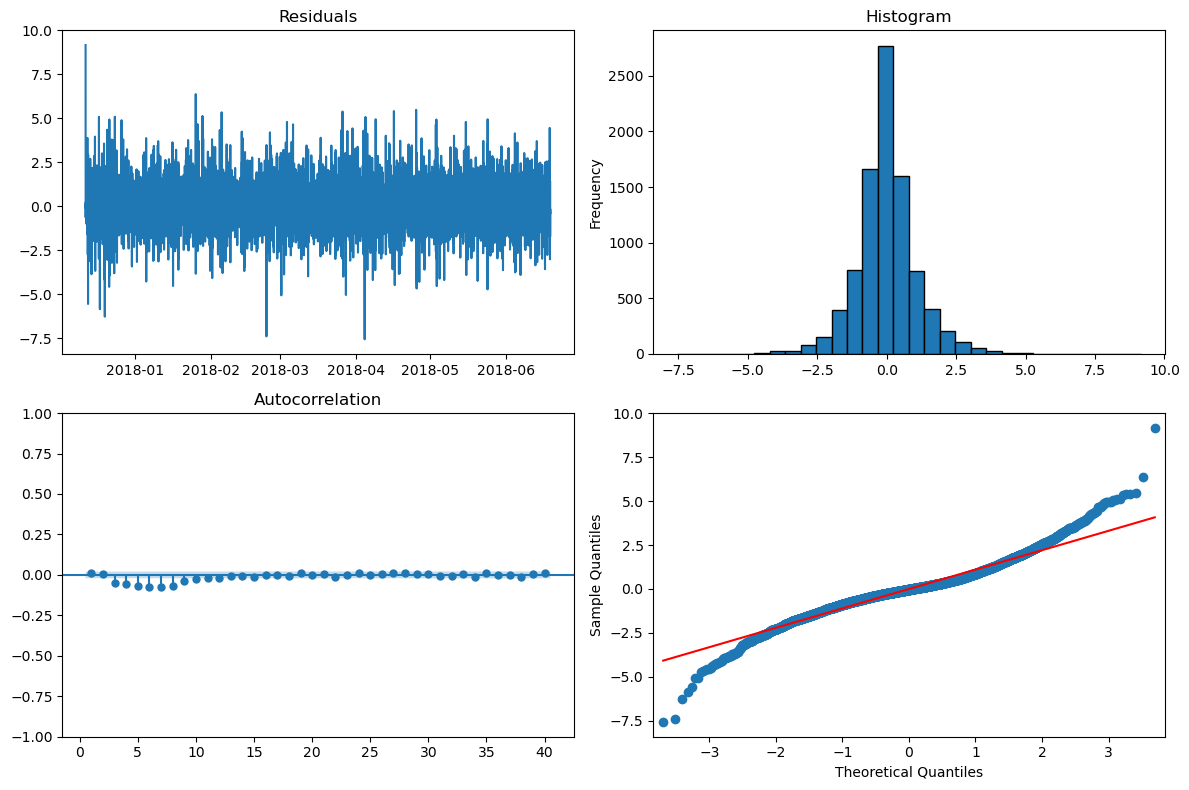

In [89]:
residuals = res.resid

fig, ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].plot(residuals)
ax[0,0].set_title("Residuals")

residuals.plot(kind='hist', bins=30, ax=ax[0,1], edgecolor='black')
ax[0,1].set_title("Histogram")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), ax=ax[1,0], zero=False)

sm.qqplot(residuals.dropna(), line="s", ax=ax[1,1])

plt.tight_layout()
plt.show()

In [90]:
pred = res.get_forecast(steps=len(test_30min))

pred_mean = pred.predicted_mean
pred_conf = pred.conf_int()

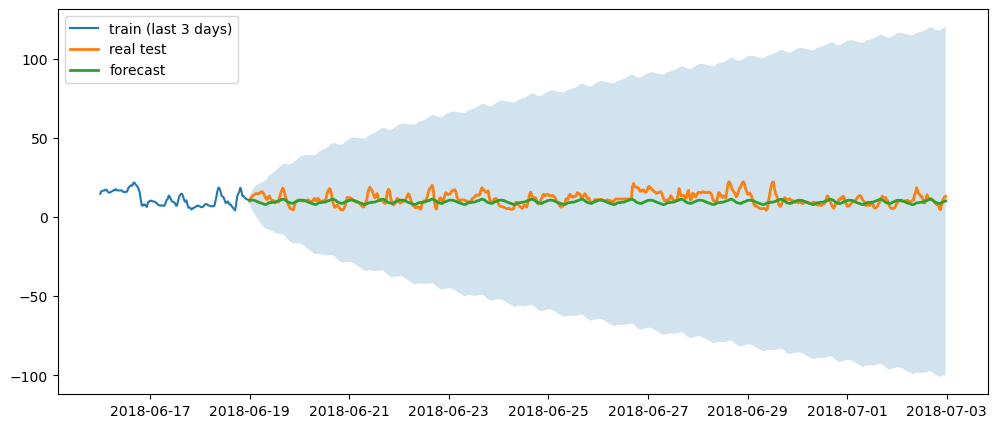

In [91]:
plt.figure(figsize=(12,5))

plt.plot(train_30min[-48*3:], label="train (last 3 days)")
plt.plot(test_30min, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)

plt.fill_between(pred_conf.index,
                 pred_conf.iloc[:,0],
                 pred_conf.iloc[:,1],
                 alpha=0.2)

plt.legend()
plt.show()

In [92]:
mae = mean_absolute_error(test_30min, pred_mean)
rmse = np.sqrt(mean_squared_error(test_30min, pred_mean))

mae, rmse
# (3.050143323855565, 3.923565038741154)

(3.050143323855565, 3.923565038741154)

### 30-min bins, 1 week splits, RMSE = 4.3645

In [102]:
train = df_res.iloc[:-288*7]
test  = df_res.iloc[-288*7:]

In [103]:
train_30min = train.resample("30min").mean()
test_30min  = test.resample("30min").mean()

In [104]:
model_30min = SARIMAX(
    train_30min,
    order=(1,1,1),
    seasonal_order=(1,1,1,48),
    simple_differencing=False,
    enforce_stationarity=True,
    enforce_invertibility=True
)

In [105]:
start = time()
res = model_30min.fit(disp=False)
end = time()
print('Model Fitting Time:', end - start)

Model Fitting Time: 328.31996273994446


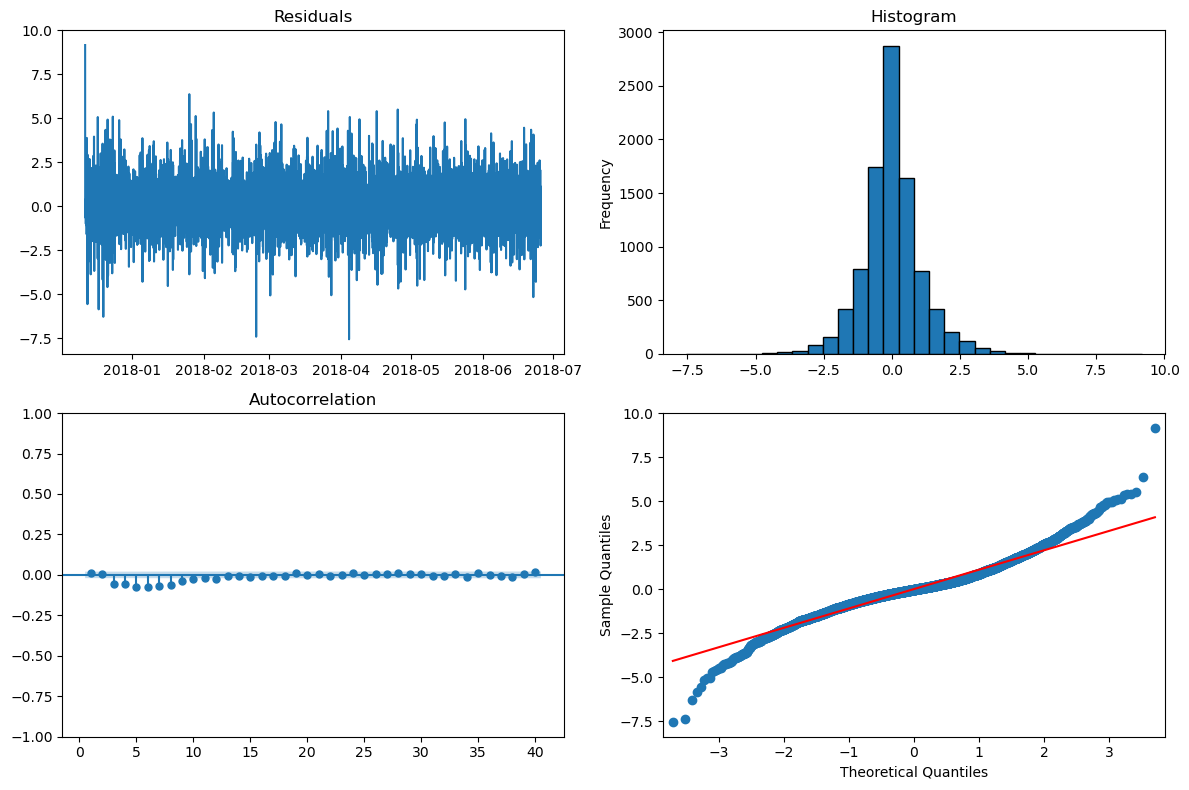

In [106]:
residuals = res.resid

fig, ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].plot(residuals)
ax[0,0].set_title("Residuals")

residuals.plot(kind='hist', bins=30, ax=ax[0,1], edgecolor='black')
ax[0,1].set_title("Histogram")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), ax=ax[1,0], zero=False)

sm.qqplot(residuals.dropna(), line="s", ax=ax[1,1])

plt.tight_layout()
plt.show()

In [107]:
pred = res.get_forecast(steps=len(test_30min))

pred_mean = pred.predicted_mean
pred_conf = pred.conf_int()

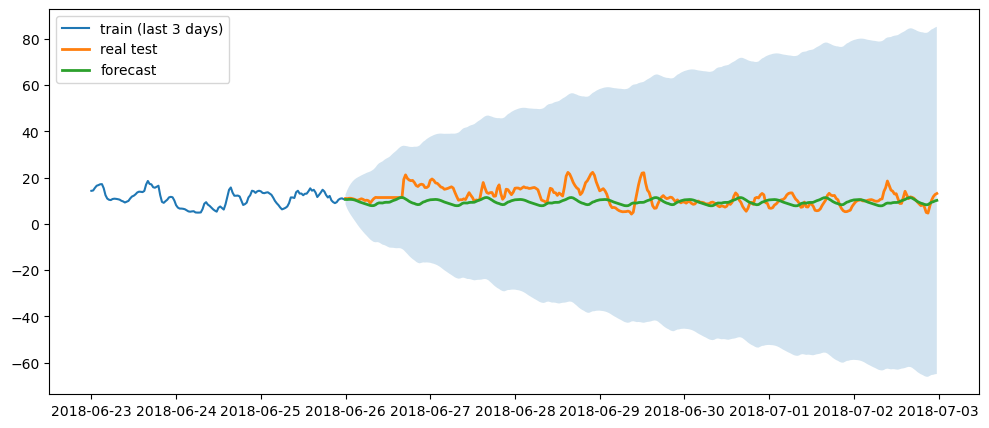

In [108]:
plt.figure(figsize=(12,5))

plt.plot(train_30min[-48*3:], label="train (last 3 days)")
plt.plot(test_30min, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)

plt.fill_between(pred_conf.index,
                 pred_conf.iloc[:,0],
                 pred_conf.iloc[:,1],
                 alpha=0.2)

plt.legend()
plt.show()

In [109]:
mae = mean_absolute_error(test_30min, pred_mean)
rmse = np.sqrt(mean_squared_error(test_30min, pred_mean))

mae, rmse
# (3.3389312277086187, 4.3644912469771375)

(3.3389312277086187, 4.3644912469771375)

### 15-min bins, 2 week splits, RMSE = 11.9

In [ ]:
train = df_res.iloc[:-288*14]
test  = df_res.iloc[-288*14:]

In [103]:
train_15min = train.resample("15min").mean()
test_15min  = test.resample("15min").mean()

In [105]:
model_15min = SARIMAX(
    train_15min,
    order=(1,1,1),
    seasonal_order=(1,1,1,96),
    simple_differencing=False,
    enforce_stationarity=True,
    enforce_invertibility=True
)

In [107]:
start = time()
res = model_15min.fit(disp=False)
end = time()
print('Model Fitting Time:', end - start)
# if simple_differencing= False
# 750.6 s 

# if simple_difference = True
# # MemoryError: Unable to allocate 5.14 GiB for an array with shape (195, 195, 18146) and data type float64

KeyboardInterrupt: 

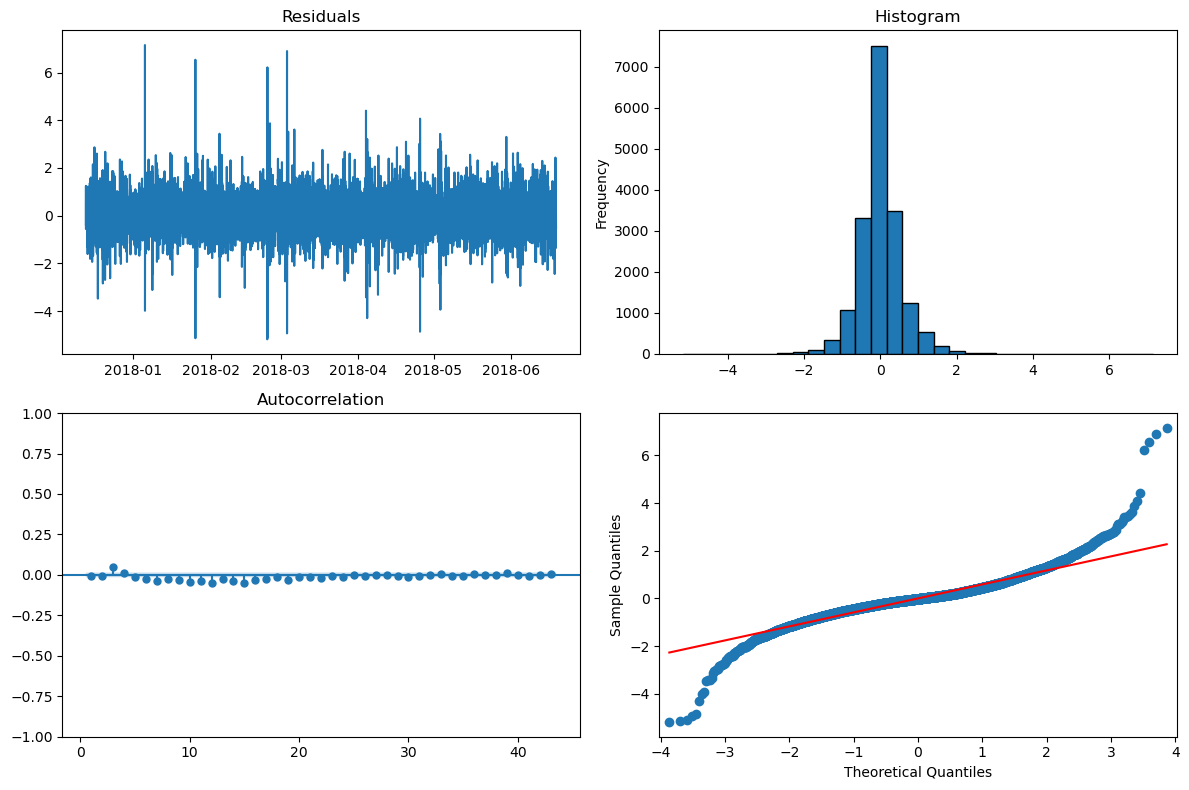

In [99]:
residuals = res.resid

fig, ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].plot(residuals)
ax[0,0].set_title("Residuals")

residuals.plot(kind='hist', bins=30, ax=ax[0,1], edgecolor='black')
ax[0,1].set_title("Histogram")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), ax=ax[1,0], zero=False)

sm.qqplot(residuals.dropna(), line="s", ax=ax[1,1])

plt.tight_layout()
plt.show()

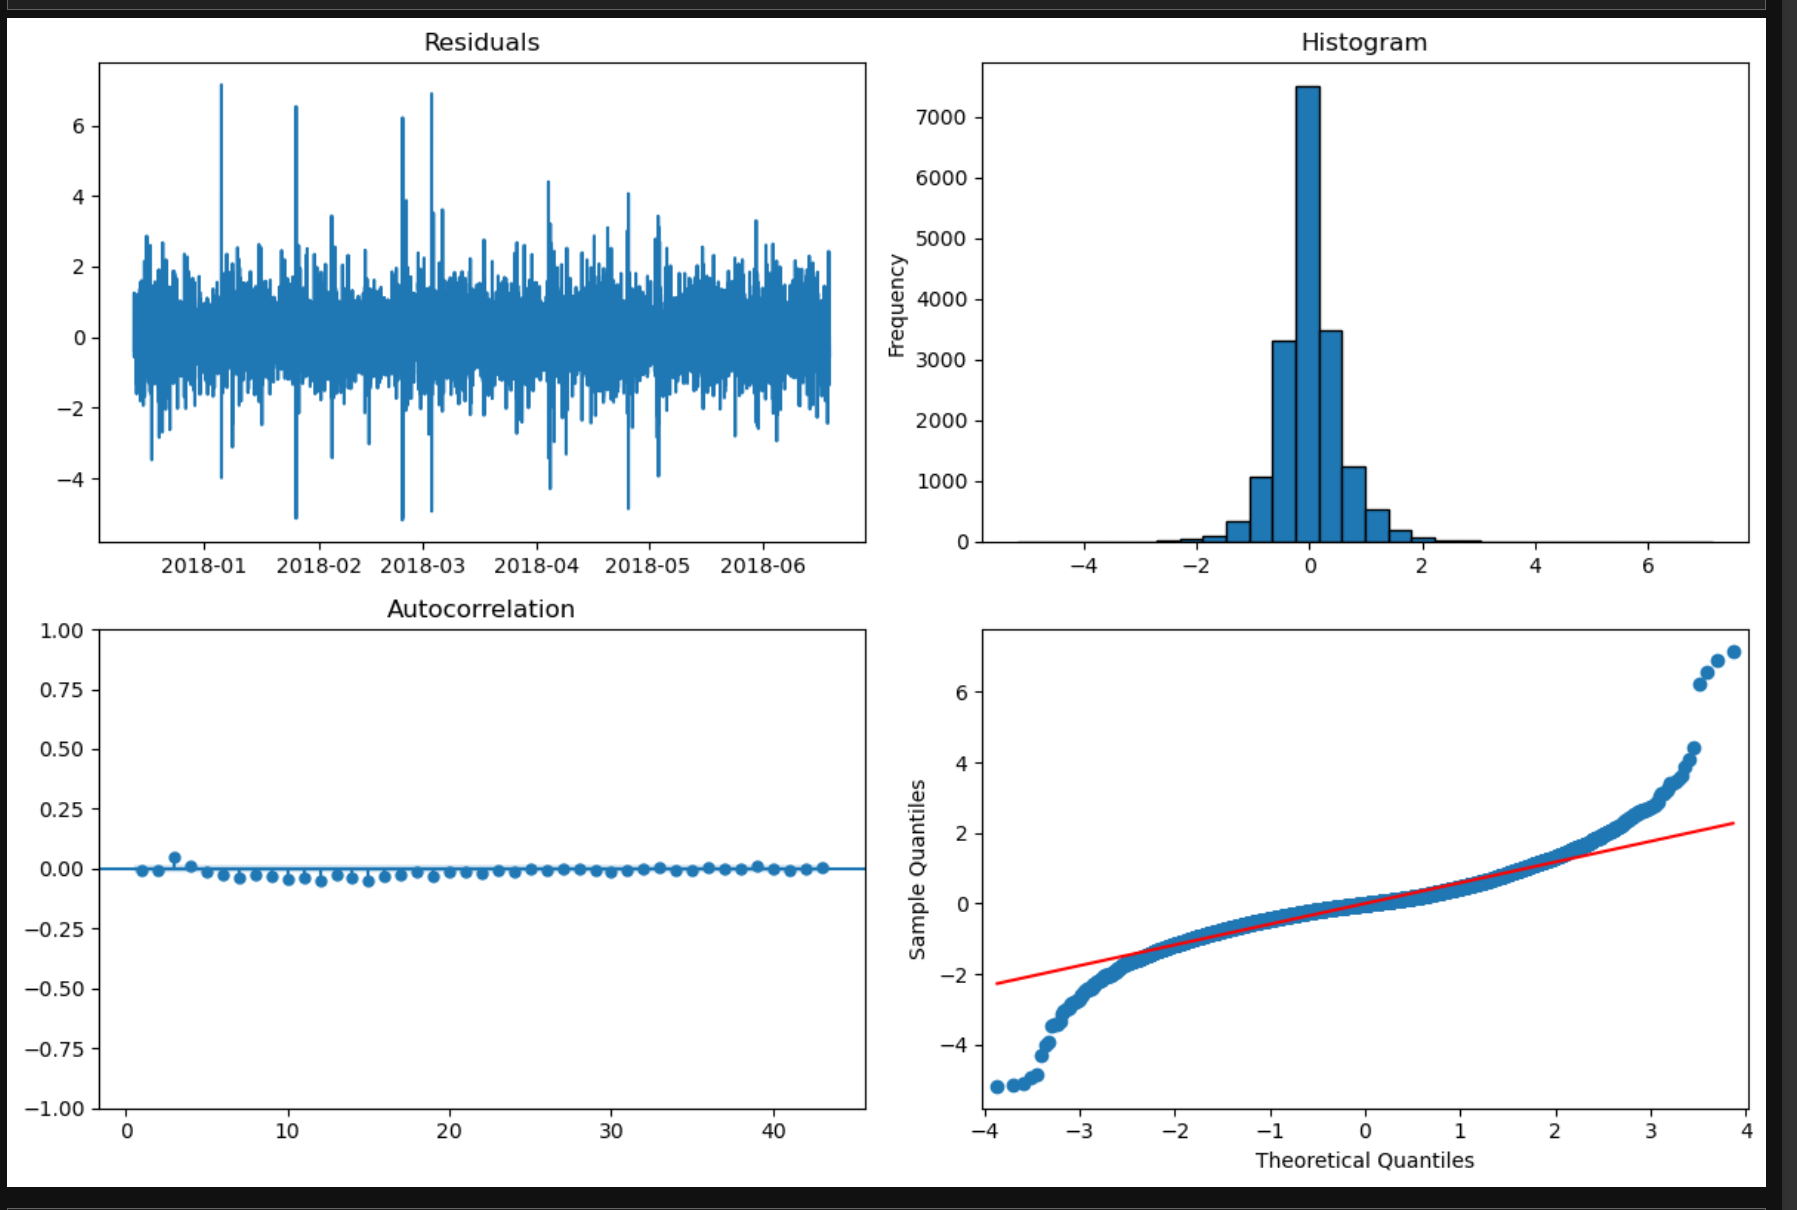

In [100]:
pred = res.get_forecast(steps=len(test_15min))
pred_mean = pred.predicted_mean
pred_conf = pred.conf_int()

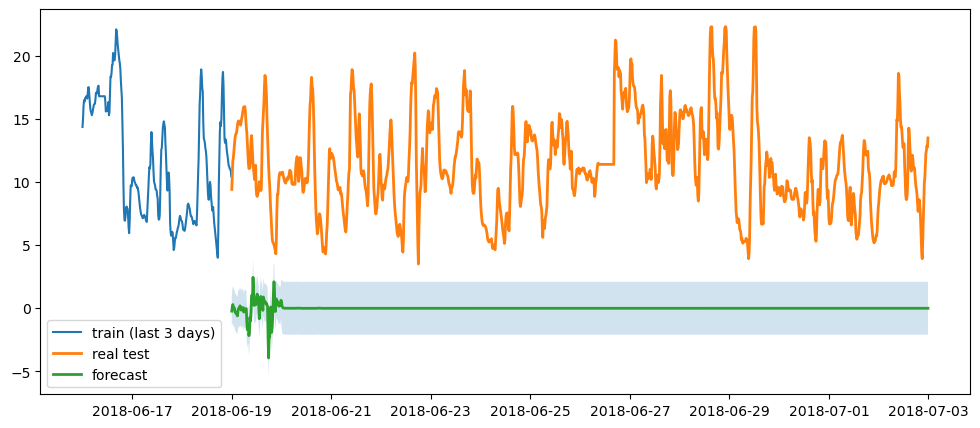

In [101]:
plt.figure(figsize=(12,5))

plt.plot(train_15min[-96*3:], label="train (last 3 days)")
plt.plot(test_15min, label="real test", linewidth=2)
plt.plot(pred_mean, label="forecast", linewidth=2)

plt.fill_between(pred_conf.index,
                 pred_conf.iloc[:,0],
                 pred_conf.iloc[:,1],
                 alpha=0.2)

plt.legend()
plt.show()

In [102]:
mae = mean_absolute_error(test_15min, pred_mean)
rmse = np.sqrt(mean_squared_error(test_15min, pred_mean))

mae, rmse
# (11.383027410462214, 11.950341777867651)

(11.383027410462214, 11.950341777867651)